<style>
.jp-RenderedMarkdown p,.jp-RenderedMarkdown li,.jp-RenderedMarkdown td,.jp-RenderedMarkdown th,.jp-RenderedMarkdown blockquote,.rendered_html p,.rendered_html li,.rendered_html td,.rendered_html th,.rendered_html blockquote{font-family:'Times New Roman',Times,serif!important;text-align:justify;line-height:1.6}
.jp-RenderedMarkdown h1,.jp-RenderedMarkdown h2,.jp-RenderedMarkdown h3,.jp-RenderedMarkdown h4,.rendered_html h1,.rendered_html h2,.rendered_html h3,.rendered_html h4{font-family:'Times New Roman',Times,serif!important}
</style>

# **The Evolution of Soros Fund Management’s US Equity Holdings (2006-2025)**

## **Table of Contents**
1. [Introduction](#1-introduction)
   - 1.1 Research Questions
2. [Data Acquisition](#2-data-acquisition)
   - 2.1 Data Description
   - 2.2 EDGAR 13F Scraper
   - 2.3 LSEG Enrichment
   - 2.4 Loading the Data
3. [Prepare the Data for Analysis](#3-prepare-the-data-for-analysis)
   - 3.1 Building the Master Dataset
   - 3.2 Data Quality & Diagnostics
   - 3.3 Initial Data Analysis
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
   - 4.1 RQ1: Portfolio Evolution (2006–2025)
   - 4.2 RQ2: Regime Analysis
   - 4.3 RQ3: Cross-Fund Comparison
   - 4.4 Explanatory Visualisations
5. [Conclusion](#5-conclusion)
   - 5.1 Key Findings
   - 5.2 Limitations
   - 5.3 What Else Could Be Done

## **1. Introduction**

Soros Fund Management (SFM) is a privately held American hedge fund founded by LSE alumnus George Soros in 1970. As one of the most influential and successful hedge funds in history, with an AUM of $28bn in 2025, SFM has intrigued us as Accounting and Finance students, encouraging us to understand the strategy behind its sustained success over the last two decades (2006–2025). This period was marked by major economic events including the 2008 Global Financial Crisis (GFC), the post-GFC bull market, the COVID-19 Pandemic, and the 2022 rate-hike cycle, requiring SFM to constantly adapt its investment approach while balancing the risk amid uncertainty. This project aims to examine and analyse SFM's investment strategy during these times and ultimately compare it to two prominent hedge funds, Pershing Square and Marshall Wace, which are known to have differing investment philosophies.

### 1.1 Research Questions

1. How has Soros Fund Management’s US equity holdings evolved in terms of market cap concentration and sector-specific allocation from 2006–2025? 
2. How did Soros Fund Management readjust its US equity holdings and portfolio concentration during major market regimes (2008 Global Financial Crisis (GFC), COVID-19 Pandemic, and the 2022 rate-hike cycle)? 
3. How does Soros Fund Management’s sector and market cap profile compare to Pershing Square and Marshall Wace from 2006-2025?

## **2. Data Acquisition**

### 2.1 Data Description

The analysis uses two main data sources: (1) **SEC EDGAR 13F mandatory disclosure filings** and (2) **LSEG Workspace fundamental reference data**.

#### 2.1.1 SEC EDGAR 13F Filings
Institutional funds with an AUM greater than $100mn, such as SFM, are legally required to disclose their long US equity positions quarterly in a 13F-HR filing. These 13F-HR filings can be found on the SEC's filing database called EDGAR. In this project, data regarding the long positions held by SFM, Pershing Square, and Marshall Wace from 2006-Q1 to 2025-Q4 was scraped from EDGAR's submissions API, resulting in 193,454 holding observations. However, note that 13F-HR filings cover US long equity positions only (no derivatives, shorts, or non-US holdings) and carry a 45-day reporting lag.

#### 2.1.2 LSEG Workspace (formerly Refinitiv)
Through the *refinitiv-data* API, we (1) matched each stock in the 13F-HR filings to its corresponding industry classification using its unique CUSIP identifier and LSEG's TRBC framework and (2) pulled each company's market capitalisation and closing stock price at the end of each calendar quarter. These point-in-time figures ensure the analysis considers information available at the time rather than revised figures, improving the accuracy and reliability of the project's final conclusion.

### 2.2 EDGAR 13F Scraper

#### 2.2.1 Scraper Design and Components
The scraper pulls all 13F-HR and 13F-HR/A filings from EDGAR for each fund between 2006 and 2025, working through the submissions API and paginating through older filing pages as needed. A 13F-HR/A is a corrective amendment to an original 13F-HR. Rather than automatically deferring to the amendment, the scraper reads every filing for a given quarter and keeps whichever contains the most holdings. This handles both additive amendments (which append previously omitted positions) and full-restatement amendments (which replace the original entirely).

Requests are capped at one call every 0.15 seconds to stay within EDGAR's 10-per-second limit, with automatic exponential back-off on 429 and 5xx responses.

Holdings come in two formats depending on filing date: post-2013 filings use the SEC's structured XML schema, while pre-2013 filings embed holdings as fixed-width text inside an SGML wrapper. The scraper handles both via a dedicated parser for each.

Finally, convertible notes (type PRN) are excluded, options are retained, and all values reported before Q4 2022 are multiplied by 1,000 to account for the SEC's shift in reporting units from thousands of dollars to whole dollars that quarter.

In [1]:
if False:
    # EDGAR 13F scraper — run once; outputs in data/edgar/. Documentation only.
    import csv, json, os, re, time, xml.etree.ElementTree as ET
    from collections import defaultdict
    from urllib.request import Request, urlopen
    from urllib.error import HTTPError, URLError
    from datetime import datetime
    FUNDS = [
        {"name": "Soros Fund Management",       "cik": "0001029160"},
        {"name": "Pershing Square",             "cik": "0001336528"},
        {"name": "Marshall Wace LLP",           "cik": "0001318757", "merge_as": "Marshall Wace"},
        {"name": "Marshall Wace North America", "cik": "0001325091", "merge_as": "Marshall Wace"},
    ]
    BASE, EDGAR = "https://data.sec.gov", "https://www.sec.gov"
    USER_AGENT = "ST115Project/1.0 (academic research; st115.student@gmail.com)"
    HEADERS    = {"User-Agent": USER_AGENT, "Accept-Encoding": "gzip, deflate"}
    START_YEAR, END_YEAR = 2006, 2025
    OUTPUT_DIR = "data/edgar"
    RATE_LIMIT, VALUE_WHOLE_DOLLAR_CUTOFF = 0.15, "2022-12-31"
    CSV_COLUMNS = ["fund","filing_date","report_date","quarter","accession_number",
                   "issuer_name","title_of_class","cusip","value_usd","shares",
                   "put_call","investment_discretion",
                   "voting_authority_sole","voting_authority_shared","voting_authority_none"]
    CUSIP_RE = re.compile(r"(?<!\S)([A-Za-z0-9]{8}[0-9])(?!\S)")
    def _is_valid_cusip(t): return bool(re.match(r"^[A-Z0-9]{8}[0-9]$", t))
    def _clean_num(s): return s.replace("$","").replace(",","").replace(" ","").strip()
    def _find_cusip(line):
        for m in CUSIP_RE.finditer(line.upper()):
            if _is_valid_cusip(m.group(1)): return m
        return None
    def quarter_label(d):
        try: dt = datetime.strptime(d, "%Y-%m-%d"); return f"{dt.year}Q{(dt.month-1)//3+1}"
        except: return ""
    def normalise_value(value_raw, report_date):
        if not value_raw: return ""
        try: v = int(_clean_num(value_raw))
        except ValueError: return value_raw
        if report_date <= VALUE_WHOLE_DOLLAR_CUTOFF: v *= 1000
        return str(v)
    def fetch(url, retries=3, backoff=2.0):
        for attempt in range(retries):
            time.sleep(RATE_LIMIT); req = Request(url, headers=HEADERS)
            try:
                with urlopen(req, timeout=30) as resp:
                    raw = resp.read()
                    if resp.headers.get("Content-Encoding") == "gzip":
                        import gzip; raw = gzip.decompress(raw)
                    return raw.decode("utf-8", errors="replace")
            except HTTPError as e:
                if e.code == 429 or e.code >= 500: time.sleep(backoff*(attempt+1)); continue
                raise
            except (URLError, TimeoutError): time.sleep(backoff*(attempt+1)); continue
        raise RuntimeError(f"Failed after {retries} retries: {url}")
    def fetch_json(url): return json.loads(fetch(url))
    def _safe_filename(n): return re.sub(r"[^a-z0-9]+","_",n.lower()).strip("_")
    def write_csv(rows, path):
        with open(path,"w",newline="",encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=CSV_COLUMNS, extrasaction="ignore")
            w.writeheader(); w.writerows(rows)
        print(f"  Saved {len(rows):,} rows -> {path}")

In [2]:
if False:
    def get_all_filings(cik):
        subs = fetch_json(f"{BASE}/submissions/CIK{cik}.json")
        r = subs["filings"]["recent"]
        forms, accns = list(r["form"]), list(r["accessionNumber"])
        fdates, rdates = list(r["filingDate"]), list(r.get("reportDate",[]))
        for fo in subs["filings"]["files"]:
            page = fetch_json(f"{BASE}/submissions/{fo['name']}")
            forms.extend(page["form"]); accns.extend(page["accessionNumber"])
            fdates.extend(page["filingDate"]); rdates.extend(page.get("reportDate",[]))
        filings = []
        for i, form in enumerate(forms):
            if form not in ("13F-HR","13F-HR/A") or i >= len(rdates): continue
            rd = rdates[i]
            if not rd or not (START_YEAR <= int(rd[:4]) <= END_YEAR): continue
            filings.append({"accessionNumber":accns[i],"filingDate":fdates[i],"reportDate":rd,"form":form})
        return sorted(filings, key=lambda f: f["filingDate"])
    def pick_best_per_quarter(filings):
        by_q = defaultdict(list)
        for f in filings:
            q = quarter_label(f["reportDate"])
            if q: by_q[q].append(f)
        result = []
        for q in sorted(by_q):
            g = by_q[q]
            amends = sorted([f for f in g if f["form"]=="13F-HR/A"], key=lambda f:f["filingDate"], reverse=True)
            origs  = sorted([f for f in g if f["form"]=="13F-HR"],   key=lambda f:f["filingDate"], reverse=True)
            entry = (amends+origs)[0].copy(); entry["_candidates"]=amends+origs; entry["_quarter"]=q
            result.append(entry)
        return result
    NS = "http://www.sec.gov/edgar/document/thirteenf/informationtable"
    def _el(el, tag):
        for n in [f"{{{NS}}}{tag}", tag]:
            c = el.find(n)
            if c is not None and c.text: return c.text.strip()
        return ""
    def _el2(el, p, c):
        for pn in [f"{{{NS}}}{p}", p]:
            pe = el.find(pn)
            if pe is not None:
                for cn in [f"{{{NS}}}{c}", c]:
                    ce = pe.find(cn)
                    if ce is not None and ce.text: return ce.text.strip()
        return ""
    def fetch_submission_text(acc, cik):
        a = acc.replace("-","")
        return fetch(f"{EDGAR}/Archives/edgar/data/{int(cik)}/{a}/{acc}.txt")
    def extract_xml_from_sgml(txt):
        for b in re.findall(r"<XML>\s*(.*?)\s*</XML>", txt, re.DOTALL|re.IGNORECASE):
            if "informationTable" in b or "infoTable" in b: return b.strip()
        return None
    def parse_xml_holdings(xml):
        for marker in ["<?xml","<informationTable","<ns1:informationTable"]:
            idx = xml.find(marker)
            if idx != -1: xml = xml[idx:]; break
        try: root = ET.fromstring(xml)
        except ET.ParseError:
            try: root = ET.fromstring(f"<root>{xml}</root>")
            except ET.ParseError: return []
        entries = root.findall(f".//{{{NS}}}infoTable") or root.findall(".//infoTable")
        out = []
        for e in entries:
            prn = (_el2(e,"shrsOrPrnAmt","sshPrnamtType") or _el2(e,"shrOrPrnAmt","sshPrnamtType") or
                   _el2(e,"shrsOrPrnAmt","sshPrntype")   or _el2(e,"shrOrPrnAmt","sshPrntype")).upper().strip()
            if prn == "PRN": continue
            out.append({"issuer_name":_el(e,"nameOfIssuer"),"title_of_class":_el(e,"titleOfClass"),
                "cusip":_el(e,"cusip"),"value_raw":_el(e,"value"),
                "shares":(_el2(e,"shrsOrPrnAmt","sshPrnamt") or _el2(e,"shrOrPrnAmt","sshPrnamt")),
                "put_call":_el(e,"putCall"),"investment_discretion":_el(e,"investmentDiscretion"),
                "voting_authority_sole":_el2(e,"votingAuthority","Sole"),
                "voting_authority_shared":_el2(e,"votingAuthority","Shared"),
                "voting_authority_none":_el2(e,"votingAuthority","None")})
        return out
    def extract_plaintext_table(txt):
        blocks = re.split(r"<DOCUMENT>", txt, flags=re.IGNORECASE)
        for b in blocks:
            m = re.search(r"<TYPE>\s*(.*?)[\r\n]", b, re.IGNORECASE)
            if m and "INFORMATION TABLE" in m.group(1).upper(): return b
        for b in blocks:
            m = re.search(r"<TYPE>\s*(.*?)[\r\n]", b, re.IGNORECASE)
            if m and m.group(1).strip().upper() in ("13F-HR","13F-HR/A"): return b
        return None
    def _is_header_or_junk(line):
        s = line.strip()
        if not s or all(c in "-=_ \t" for c in s): return True
        u = s.upper()
        for ph in ["NAME OF ISSUER","TITLE OF CLASS","CUSIP","FAIR MARKET","VALUE (","SHARES OR",
                   "SHRS OR","SH/ PUT","INVESTMENT DISC","VOTING AUTH","COLUMN ","<TEXT>","<PAGE>",
                   "FORM 13F","INFORMATION TABLE","QUARTER ENDED","REPORT PERIOD","<S>","<C>"]:
            if ph in u and not _find_cusip(s): return True
        return False
    def parse_plaintext_holdings(table_text):
        holdings = []; buf = []
        for line in table_text.split("\n"):
            raw = line.rstrip()
            if _is_header_or_junk(raw): buf = []; continue
            m = _find_cusip(raw)
            if m is None:
                if raw.strip(): buf.append(raw.strip())
                continue
            cusip = m.group(1); cpos = raw.upper().find(cusip)
            left = [p.strip() for p in re.split(r"\s{2,}", raw[:cpos].strip()) if p.strip()]
            pre  = [p.strip() for pl in buf for p in re.split(r"\s{2,}", pl) if p.strip()]
            if pre:
                issuer = (" ".join(pre)+" "+left[0]).strip() if left else " ".join(pre)
                title  = " ".join(left[1:]) if len(left) > 1 else ""
            elif len(left) >= 2: issuer = left[0]; title = " ".join(left[1:])
            elif left: issuer = left[0]; title = ""
            else: issuer = title = ""
            tokens = raw[cpos+9:].replace("$","").split()
            nums  = [_clean_num(t) for t in tokens if re.match(r"^\d+$",_clean_num(t)) and _clean_num(t)]
            words = [t.upper().strip() for t in tokens if not re.match(r"^[\d,]+$",t.replace("$","").strip())]
            if "PRN" in words: buf = []; continue
            put_call = "Put" if "PUT" in words else ("Call" if "CALL" in words else "")
            disc = next((l for l in ["SOLE","DFND","DEFINED","SHARED","OTHER"] if l in words),"")
            holdings.append({"issuer_name":issuer,"title_of_class":title,"cusip":cusip,
                "value_raw":nums[0] if nums else "","shares":nums[1] if len(nums)>1 else "",
                "put_call":put_call,"investment_discretion":disc,
                "voting_authority_sole":nums[2] if len(nums)>2 else "",
                "voting_authority_shared":nums[3] if len(nums)>3 else "",
                "voting_authority_none":nums[4] if len(nums)>4 else ""})
            buf = []
        return holdings
    def process_filing(filing, cik):
        acc, fd = filing["accessionNumber"], filing["filingDate"]
        rd, q = filing["reportDate"], quarter_label(filing["reportDate"])
        txt = fetch_submission_text(acc, cik)
        hs = parse_xml_holdings(extract_xml_from_sgml(txt)) or \
             parse_plaintext_holdings(extract_plaintext_table(txt)) or []
        for h in hs:
            h.update({"filing_date":fd,"report_date":rd,"quarter":q,"accession_number":acc,
                      "value_usd":normalise_value(h.pop("value_raw"),rd)})
        return hs
    def process_all(entries, cik):
        all_rows = []
        for entry in entries:
            best = []
            for c in entry["_candidates"]:
                try: rows = process_filing(c, cik)
                except Exception as ex: print(f"  Error {c['accessionNumber']}: {ex}"); rows=[]
                if len(rows) > len(best): best = rows
            all_rows.extend(best)
        return all_rows
    for fund in FUNDS:
        rows = process_all(pick_best_per_quarter(get_all_filings(fund["cik"])), fund["cik"])
        for r in rows: r["fund"] = fund["name"]
        write_csv(rows, os.path.join(OUTPUT_DIR, f"{_safe_filename(fund['name'])}_13f_{START_YEAR}_{END_YEAR}.csv"))
    # Output: data/edgar/combined_13f_2006_2025.csv

**Scraper output (from original collection run):**
```
Soros Fund Management  — 86 filings → 80 unique quarters → 20,907 rows
Pershing Square        — 95 filings → 80 unique quarters →    931 rows
Marshall Wace LLP      — 85 filings → 78 unique quarters → 119,259 rows
Marshall Wace N. Am.   — 61 filings → 51 unique quarters →  52,357 rows
Marshall Wace (merged) — 171,616 combined holdings
Combined (all funds)   — 193,454 total holdings
```

### 2.3 LSEG Enrichment

The cells below contain the full LSEG data collection process. Each cell begins with an `if False` statement as it requires LSEG Workspace to be installed and running (this project accesses the LSEG Workspace through the LSE Library). The code was executed once, with all output saved to `data/lseg/` and loaded in Section 2.4. The data quality summary, shown in the final cell, reads from the saved output file and can be re-run without accessing the LSEG Workspace.

#### 2.3.1 Collection Steps
The collection process runs four steps: (1) 11,974 unique CUSIP stock identifiers were converted into Refinitiv's unique stock identifier codes called RICs, with 98.6% of stocks matched to a RIC and 81.0% having TRBC sector data, (2) 372,803 quarterly price observations were fetched across 9,449 RICs, (3) 493,640 market capitalisation observations were fetched across 8,774 RICs, and (4) a coverage check showing 90.8% RIC matches, 87.4% sector matches, 89.9% price matches, and 87.8% market capitalisation matches. Between 2006-2010, coverage was lower at ~78% but rose to ~95% after 2021. 

**Steps 1–2: Session setup and CUSIP-to-RIC mapping**

In [3]:
if False:  # Requires live LSEG Workspace — data saved to data/lseg/
    # pip install refinitiv-data
    import refinitiv.data as rd
    import pandas as pd, os, time
    rd.open_session()
    OUTPUT_DIR = "data/lseg"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    df = pd.read_csv("data/edgar/combined_13f_2006_2025.csv", dtype={"cusip": str})
    cusips = [c for c in sorted(df["cusip"].dropna().unique()) if len(c) == 9]
    print(f"{len(cusips)} unique CUSIPs to map")
    FIELDS = ["TR.RIC","TR.CommonName","TR.TRBCEconomicSector","TR.TRBCBusinessSector",
              "TR.TRBCIndustryGroup","TR.TRBCIndustry"]
    frames = []
    for i in range(0, len(cusips), 200):
        try:
            r = rd.get_data(cusips[i:i+200], fields=FIELDS)
            if r is not None and not r.empty: frames.append(r)
        except Exception as e: print(f"Batch {i}: {e}")
        time.sleep(0.3)
    raw_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    col_rename = {
        "Instrument":"cusip","RIC":"ric","Common Name":"company_name",
        "TRBC Economic Sector Name":"trbc_economic_sector","TRBC Business Sector Name":"trbc_business_sector",
        "TRBC Industry Group Name":"trbc_industry_group","TRBC Industry Name":"trbc_industry",
        "TR.RIC":"ric","TR.CommonName":"company_name","TR.TRBCEconomicSector":"trbc_economic_sector",
        "TR.TRBCBusinessSector":"trbc_business_sector","TR.TRBCIndustryGroup":"trbc_industry_group",
        "TR.TRBCIndustry":"trbc_industry",
    }
    mapping = raw_df.rename(columns=col_rename).drop_duplicates(subset="cusip", keep="first")
    unmatched = pd.DataFrame({"cusip": [c for c in cusips if c not in set(mapping["cusip"].dropna())]})
    mapping = pd.concat([mapping, unmatched], ignore_index=True).sort_values("cusip").reset_index(drop=True)
    mapping.to_csv(os.path.join(OUTPUT_DIR, "cusip_ric_mapping.csv"), index=False)
    total, with_ric = len(mapping), mapping["ric"].notna().sum()
    print(f"{total} CUSIPs | {with_ric} with RIC ({with_ric/total:.1%}) | {mapping['trbc_economic_sector'].notna().sum()} with sector")

**Steps 3–4: Historical quarterly prices**

In [4]:
if False:  # Requires live LSEG Workspace — data saved to data/lseg/
    import csv
    rics = sorted(pd.read_csv(os.path.join(OUTPUT_DIR,"cusip_ric_mapping.csv"), dtype=str)["ric"].dropna().unique())
    PRICES_FILE = os.path.join(OUTPUT_DIR, "quarterly_prices.csv")
    all_frames = []
    for i in range(0, len(rics), 300):
        try:
            r = rd.get_history(universe=rics[i:i+300], fields=["TRDPRC_1"], interval="monthly",
                               start="2006-01-01", end="2025-12-31")
            if r is not None and not r.empty:
                df = r.copy(); df.index = pd.to_datetime(df.index)
                df = df[df.index.month.isin([3,6,9,12])].groupby([df.index.year, df.index.month]).tail(1)
                all_frames.append(df)
        except Exception as e: print(f"Batch {i}: {e}")
        time.sleep(0.5)
    row_count = 0; ric_set = set()
    with open(PRICES_FILE, "w", newline="") as f:
        w = csv.writer(f); w.writerow(["ric","date","quarter","close_price"])
        for df in all_frames:
            df.index = pd.to_datetime(df.index)
            for col in df.columns:
                for dt, val in df[col].dropna().items():
                    w.writerow([col, dt.strftime("%Y-%m-%d"), f"{dt.year}Q{(dt.month-1)//3+1}", val])
                    row_count += 1; ric_set.add(col)
    print(f"Saved {PRICES_FILE}: {row_count} observations, {len(ric_set)} RICs")

**Steps 5–6: Point-in-time market capitalisation**

In [5]:
if False:  # Requires live LSEG Workspace — data saved to data/lseg/
    import csv
    MKTCAP_FILE = os.path.join(OUTPUT_DIR, "quarterly_market_cap.csv")
    mktcap_frames = []
    for i in range(0, len(rics), 300):
        try:
            r = rd.get_data(universe=rics[i:i+300],
                            fields=["TR.CompanyMarketCap","TR.CompanyMarketCap.Date"],
                            parameters={"SDate":"2006-01-01","EDate":"2025-12-31","Frq":"CQ"})
            if r is not None and not r.empty: mktcap_frames.append(r)
        except Exception as e: print(f"Batch {i}: {e}")
        time.sleep(0.5)
    row_count = 0; ric_set = set()
    with open(MKTCAP_FILE, "w", newline="") as f:
        w = csv.writer(f); w.writerow(["ric","date","quarter","market_cap"])
        for df in mktcap_frames:
            rename = {c: ("ric" if c=="Instrument" else "date" if "date" in c.lower()
                          else "market_cap" if "market" in c.lower() or "companym" in c.lower() else c)
                      for c in df.columns}
            df = df.rename(columns=rename)
            for _, row in df.iterrows():
                ric, dt, mc = row.get("ric"), row.get("date"), row.get("market_cap")
                if pd.isna(ric) or pd.isna(dt) or pd.isna(mc): continue
                dt = pd.to_datetime(dt)
                w.writerow([ric, dt.strftime("%Y-%m-%d"), f"{dt.year}Q{(dt.month-1)//3+1}", mc])
                row_count += 1; ric_set.add(ric)
    print(f"Saved {MKTCAP_FILE}: {row_count} observations, {len(ric_set)} RICs")

**Step 7: Data quality and coverage summary**

In [6]:
# Data quality summary
# Full coverage analysis was computed during the collection run and saved.
notes_file = "data/lseg/data_quality_notes.txt"
with open(notes_file) as f:
    print(f.read())

DATA QUALITY SUMMARY

Total holding rows: 193,454
Unique CUSIPs:     11,974
Unique RICs:       9,554
Funds:             3
Quarters:          80

Metric                            Missing   Coverage
----------------------------------------------------
RIC match                          17,732      90.8%
TRBC sector                        24,420      87.4%
Quarterly price                    19,568      89.9%
Quarterly market cap               23,594      87.8%

COVERAGE BY FUND

Fund                             Holdings      RIC   Sector    Price   MktCap
--------------------------------------------------------------------------
Marshall Wace                     171,616    91.9%    88.3%    90.9%    88.8%
Pershing Square                       931    70.9%    71.8%    69.4%    70.9%
Soros Fund Management              20,907    83.1%    80.4%    82.1%    80.4%

COVERAGE BY TIME PERIOD

Period            Holdings      RIC   Sector    Price   MktCap
------------------------------------------

### 2.4 Loading the Data
Data from Sections 2.2 and 2.3 is loaded here, and the full analysis builds on four data tables. As previously mentioned, the LSEG cells are pre-executed, so to reproduce the output without LSEG, install `requirements.txt` from the folder and Section 3 onwards will run without the need for any API keys.

In [7]:
import pandas as pd
holdings = pd.read_csv("data/edgar/combined_13f_2006_2025.csv", dtype={"cusip": str})
mapping  = pd.read_csv("data/lseg/cusip_ric_mapping.csv", dtype={"cusip": str, "ric": str})
prices   = pd.read_csv("data/lseg/quarterly_prices.csv", dtype={"ric": str})
mktcap   = pd.read_csv("data/lseg/quarterly_market_cap.csv", dtype={"ric": str})
print(f"Holdings: {len(holdings):,} rows")
print(f"Mapping:  {len(mapping):,} rows")
print(f"Prices:   {len(prices):,} rows")
print(f"Mktcap:   {len(mktcap):,} rows")

Holdings: 193,454 rows
Mapping:  11,974 rows
Prices:   372,803 rows
Mktcap:   493,640 rows


## **3. Prepare the Data for Analysis**
The master dataset is built here by merging EDGAR 13F-HR holdings with LSEG sector, price, and market cap data using the mapping table outlined above to map CUSIPs to RICs. Other portfolio metrics (weights, HHI, turnover, and position changes) are also computed and added to the master dataset.

### 3.1 Building the Master Dataset

In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
holdings      = pd.read_csv('data/edgar/combined_13f_2006_2025.csv')
cusip_mapping = pd.read_csv('data/lseg/cusip_ric_mapping.csv')
prices        = pd.read_csv('data/lseg/quarterly_prices.csv')
market_cap    = pd.read_csv('data/lseg/quarterly_market_cap.csv')
holdings['report_date'] = pd.to_datetime(holdings['report_date'])
holdings['report_year'] = holdings['report_date'].dt.year
holdings = holdings[holdings['put_call'].isna()]
# Build master dataset
master_df = holdings.merge(cusip_mapping, on='cusip', how='left')
master_df['quarter'] = master_df['report_date'].dt.to_period('Q').astype(str)
master_df = master_df.merge(prices[['ric','quarter','close_price']], on=['ric','quarter'], how='left')
master_df = master_df.merge(market_cap[['ric','quarter','market_cap']], on=['ric','quarter'], how='left')
def get_mkt_cap_category(val):
    if pd.isna(val): return 'Unknown'
    return 'Large Cap' if val > 10_000_000_000 else 'Mid Cap' if val >= 2_000_000_000 else 'Small Cap'
master_df['mkt_cap_category'] = master_df['market_cap'].apply(get_mkt_cap_category)
master_df['total_fund_value'] = master_df.groupby(['fund','quarter'])['value_usd'].transform('sum')
master_df['weight'] = master_df['value_usd'] / master_df['total_fund_value']
master_df = master_df.sort_values(['fund','cusip','quarter'])
master_df['previous_shares'] = master_df.groupby(['fund','cusip'])['shares'].shift(1).fillna(0)
master_df['position_change'] = np.select(
    [master_df['previous_shares']==0, master_df['shares']>master_df['previous_shares'],
     master_df['shares']<master_df['previous_shares']], ['New','Addition','Reduction'], default='Maintain')
master_df['prev_val'] = master_df.groupby(['fund','cusip'])['value_usd'].shift(1).fillna(0)
master_df['sale_value'] = (master_df['value_usd'] - master_df['prev_val']).clip(upper=0).abs()
master_df['turnover_rate'] = master_df.groupby(['fund','quarter'])['sale_value'].transform('sum') / master_df['total_fund_value']
master_df['hhi'] = master_df.groupby(['fund','quarter'])['weight'].transform(lambda x: (x**2).sum())
master_df.drop(columns=['prev_val','sale_value'], inplace=True)

### 3.2 Data Quality & Diagnostics

In [9]:
master_df['fund'] = master_df['fund'].replace({
    'Pershing Square Capital Management, L.P.': 'Pershing Square',
    'SOROS FUND MANAGEMENT LLC': 'Soros Fund Management',
    'MARSHALL WACE LLP': 'Marshall Wace'
})
print(f"Master dataset: {master_df.shape[0]:,} rows x {master_df.shape[1]} cols")
print(f"Duplicates: {master_df.duplicated().sum():,}")
coverage = {c: f"{master_df[c].notna().mean():.1%}" for c in ['ric','trbc_economic_sector','close_price','market_cap']}
print("LSEG coverage:", coverage)
os.makedirs('data/processed', exist_ok=True)
master_df.to_csv('data/processed/master_dataset.csv', index=False)

Master dataset: 179,891 rows x 31 cols
Duplicates: 1,759
LSEG coverage: {'ric': '90.9%', 'trbc_economic_sector': '89.2%', 'close_price': '89.9%', 'market_cap': '89.8%'}


After CUSIP to RIC matching, the number of observations drops from 193,454 to 179,891, with ~13,500 holdings excluded from sector price and market cap analyses due to insufficient data matches. LSEG coverage is ~89% and the remaining holdings are small and illiquid with a minor portfolio weight.

### 3.3 Initial Data Analysis

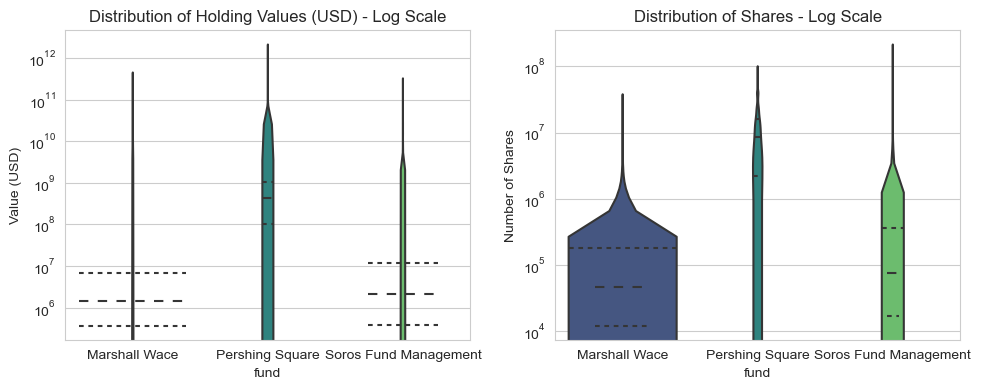

In [10]:
sns.set_style("whitegrid")
palette = "viridis"
# Combine violin plots into one figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Subplot 1: Value USD
sns.violinplot(data=master_df, x='fund', y='value_usd', palette=palette, inner='quartile', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Distribution of Holding Values (USD) - Log Scale')
axes[0].set_ylabel('Value (USD)')
# Subplot 2: Shares
sns.violinplot(data=master_df, x='fund', y='shares', palette=palette, inner='quartile', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Distribution of Shares - Log Scale')
axes[1].set_ylabel('Number of Shares')
plt.tight_layout()
plt.savefig('combined_violins.png')

*Figure 1: Violin plots showing holding value distributions (log scale) across the three funds.*
    
All three funds generally have a few large positions and many smaller ones resulting in right-skewed distributions. However, Pershing Square's holdings are generally a lot larger in value than that of Marshall Wace, as suggested by the greater density in higher values on the left violin plot, while SFM sits between the two.

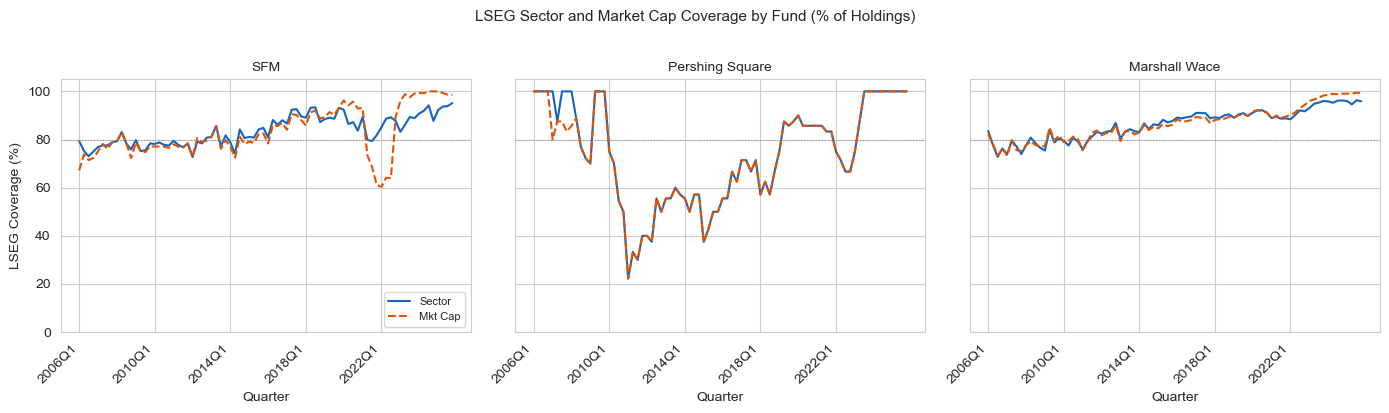

In [11]:
# LSEG sector and market cap coverage by fund and quarter (IDA data-quality check)
coverage_q = (
    master_df.groupby(['fund', 'quarter'])
    .agg(
        total=('cusip', 'count'),
        has_sector=('trbc_economic_sector', lambda x: x.notna().sum()),
        has_mktcap=('market_cap',            lambda x: x.notna().sum()),
    )
    .reset_index()
)
coverage_q['sector_pct'] = coverage_q['has_sector'] / coverage_q['total'] * 100
coverage_q['mktcap_pct']  = coverage_q['has_mktcap']  / coverage_q['total'] * 100
fund_labels = {
    'Soros Fund Management': 'SFM',
    'Pershing Square':       'Pershing Square',
    'Marshall Wace':         'Marshall Wace',
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (fund, label) in zip(axes, fund_labels.items()):
    sub = coverage_q[coverage_q['fund'] == fund].sort_values('quarter')
    x   = range(len(sub))
    ax.plot(x, sub['sector_pct'], color='#1565C0', lw=1.5, label='Sector')
    ax.plot(x, sub['mktcap_pct'],  color='#E65100', lw=1.5, ls='--', label='Mkt Cap')
    ax.axhline(80, color='grey', lw=0.8, ls=':', alpha=0.7)
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_xlabel('Quarter')
    if fund == 'Soros Fund Management':
        ax.set_ylabel('LSEG Coverage (%)')
    qs        = list(sub['quarter'])
    tick_step = max(1, len(qs) // 5)
    ax.set_xticks(range(0, len(qs), tick_step))
    ax.set_xticklabels([qs[i] for i in range(0, len(qs), tick_step)], rotation=45, ha='right')
axes[0].legend(loc='lower right', fontsize=8)
fig.suptitle('LSEG Sector and Market Cap Coverage by Fund (% of Holdings)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('lseg_coverage.png', bbox_inches='tight')

*Figure 2: Quarterly LSEG data coverage (sector and market cap) by fund, 2006 Q1–2025 Q4.*

Generally, across all three funds, coverage seems to improve over time as LSEG's data collection likely improves. Pershing Square's coverage fluctuates significantly more than the other two funds, reflecting its highly concentrated holdings. SFM and Marshall Wace experienced consistent coverage growth oscillating between 70%-100%, showcasing diversification. However, SFM faces a major dip in 2022 due to increased investment in SPACs (companies created for the sole purpose of acquiring other companies).

## **4. Exploratory Data Analysis**
The following code sets up the environment for the Exploratory Data Analysis (EDA).

In [12]:
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
SOURCE_NOTE = 'Source: SEC EDGAR 13F filings; LSEG TRBC sector classifications'
FIGURES_DIR = 'figures'
import os; os.makedirs(FIGURES_DIR, exist_ok=True)
SECTOR_PALETTE = {
    'Technology':                      '#2196F3',
    'Financials':                      '#FF9800',
    'Healthcare':                      '#4CAF50',
    'Energy':                          '#F44336',
    'Consumer Cyclicals':              '#9C27B0',
    'Consumer Non-Cyclicals':          '#795548',
    'Industrials':                     '#607D8B',
    'Basic Materials':                 '#FF5722',
    'Real Estate':                     '#009688',
    'Utilities':                       '#00BCD4',
    'Academic & Educational Services': '#E91E63',
    'Other':                           '#BDBDBD',
}
MKTCAP_PALETTE = {
    'Large Cap': '#1565C0',
    'Mid Cap':   '#64B5F6',
    'Small Cap': '#BBDEFB',
    'Unknown':   '#CFD8DC',
}
REGIMES = [
    ('Pre-GFC',                     '2006Q1', '2007Q2', '#AED6F1', 'Pre-GFC'),
    ('GFC',                         '2007Q3', '2009Q2', '#F1948A', 'GFC'),
    ('Post-GFC Bull Market',        '2009Q3', '2019Q4', '#A9DFBF', 'Post-GFC Bull Mkt'),
    ('COVID',                       '2020Q1', '2021Q2', '#F9E79F', 'COVID'),
    ('Rate Hike Cycle',             '2021Q3', '2023Q4', '#D2B4DE', 'Rate Hike Cycle'),
    ('Post-Tightening Bull Market', '2024Q1', '2025Q4', '#FAD7A0', 'Post-Tightening'),
]
REGIME_COLORS = {r[0]: r[3] for r in REGIMES}
def assign_regime(q):
    for name, start, end, *_ in REGIMES:
        if start <= q <= end:
            return name
    return 'Unclassified'
def add_regime_lines(ax, quarters, label_ypos=0.98, label_size=8.0, color='#333333', above_plot=False):
    q_list = list(quarters)
    ymin, ymax = ax.get_ylim()
    y_label = ymin + (ymax - ymin) * label_ypos
    for name, start, end, _, short in REGIMES:
        if start not in q_list:
            continue
        x_start = q_list.index(start)
        ax.axvline(x_start, color=color, lw=1.3, ls=':', zorder=3, alpha=0.90)
        if above_plot:
            ax.text(x_start + 0.4, 1.01, short,
                    ha='left', va='bottom', fontsize=label_size,
                    color='#1A1A1A', style='italic', zorder=4, clip_on=False,
                    transform=ax.get_xaxis_transform())
        else:
            ax.text(x_start + 0.4, y_label, short,
                    ha='left', va='top', fontsize=label_size,
                    color='#1A1A1A', style='italic', zorder=4, clip_on=True)
master       = master_df.copy()
sfm          = master[master['fund'] == 'Soros Fund Management'].copy()
pershing     = master[master['fund'] == 'Pershing Square'].copy()
marshall     = master[master['fund'] == 'Marshall Wace'].copy()
all_quarters = sorted(sfm['quarter'].unique(), key=lambda q: (int(q[:4]), int(q[5])))
quarter_idx  = {q: i for i, q in enumerate(all_quarters)}
sfm['q_idx']  = sfm['quarter'].map(quarter_idx)
sfm['regime'] = sfm['quarter'].apply(assign_regime)
sfm['trbc_economic_sector'] = sfm['trbc_economic_sector'].fillna('Other')
year_ticks  = [i for i, q in enumerate(all_quarters) if q.endswith('Q1')]
year_labels = [all_quarters[i][:4] for i in year_ticks]
plt.rcParams.update({
    'figure.facecolor': 'white',   'axes.facecolor': '#F7F7F7',  'axes.grid': False,
    'axes.spines.top':  False,     'axes.spines.right': False,   'axes.edgecolor': '#CCCCCC',
    'axes.titlesize':   14,        'axes.titleweight': 'bold',   'axes.titlepad': 12,
    'axes.labelsize':   11,        'axes.labelpad': 6,           'xtick.labelsize': 9,
    'ytick.labelsize':  9,         'legend.fontsize': 9,         'legend.framealpha': 0.9,
    'legend.edgecolor': '#CCCCCC', 'figure.dpi': 120,
})
print(f'EDA ready: {len(sfm):,} SFM rows | {len(all_quarters)} quarters | {sfm["regime"].nunique()} regimes')

EDA ready: 19,618 SFM rows | 80 quarters | 6 regimes


### 4.1 RQ1: Portfolio Evolution (2006-2025)
RQ1 is "**How has Soros Fund Management’s US equity holdings evolved in terms of market cap concentration and sector-specific allocation from 2006-2025?**" 

In the visualisations below, regime boundaries are marked on all time-series with dotted vertical lines.

In [13]:
# ── Regime-level descriptive statistics ───────────────────────────────────────────────
regime_stats = []
for name, start, end, *_ in REGIMES:
    sub = sfm[sfm["regime"] == name]
    avg_holdings = sub.groupby("quarter")["cusip"].nunique().mean()
    avg_hhi      = sub.groupby("quarter")["hhi"].first().mean()
    dom_sector   = sub.groupby("trbc_economic_sector")["value_usd"].sum().idxmax()
    lc_pct       = (sub[sub["mkt_cap_category"] == "Large Cap"]["value_usd"].sum()
                    / sub["value_usd"].sum() * 100)
    regime_stats.append({
        "Regime":          name,
        "Window":          f"{start}–{end}",
        "Quarters":        sub["quarter"].nunique(),
        "Avg Holdings":    round(avg_holdings),
        "Avg HHI":         round(avg_hhi, 4),
        "Dominant Sector": dom_sector,
        "Large Cap %":     round(lc_pct, 1),
    })
stats_df = pd.DataFrame(regime_stats).set_index("Regime")
display(stats_df.style
    .set_caption("Table 1 — Regime-Level Portfolio Statistics (Soros Fund Management)")
    .format({"Avg HHI": "{:.4f}", "Large Cap %": "{:.1f}%"})
    .set_properties(**{"font-size": "10pt"}))
print(f"Overall avg HHI     : {sfm.groupby('quarter')['hhi'].first().mean():.4f}")
print(f"Overall avg holdings: {sfm.groupby('quarter')['cusip'].nunique().mean():.0f}")

,Window,Quarters,Avg Holdings,Avg HHI,Dominant Sector,Large Cap %
Regime,,,,,,
Pre-GFC,2006Q1–2007Q2,6,298,0.0379,Other,24.6%
GFC,2007Q3–2009Q2,8,242,0.0926,Energy,57.5%
Post-GFC Bull Market,2009Q3–2019Q4,42,284,0.0437,Technology,50.9%
COVID,2020Q1–2021Q2,6,130,0.0748,Consumer Cyclicals,80.8%
Rate Hike Cycle,2021Q3–2023Q4,10,165,0.0629,Consumer Cyclicals,75.8%
Post-Tightening Bull Market,2024Q1–2025Q4,8,152,0.0245,Technology,76.0%


Overall avg HHI     : 0.0510
Overall avg holdings: 241


#### 4.1.1 Sector Allocation Over Time

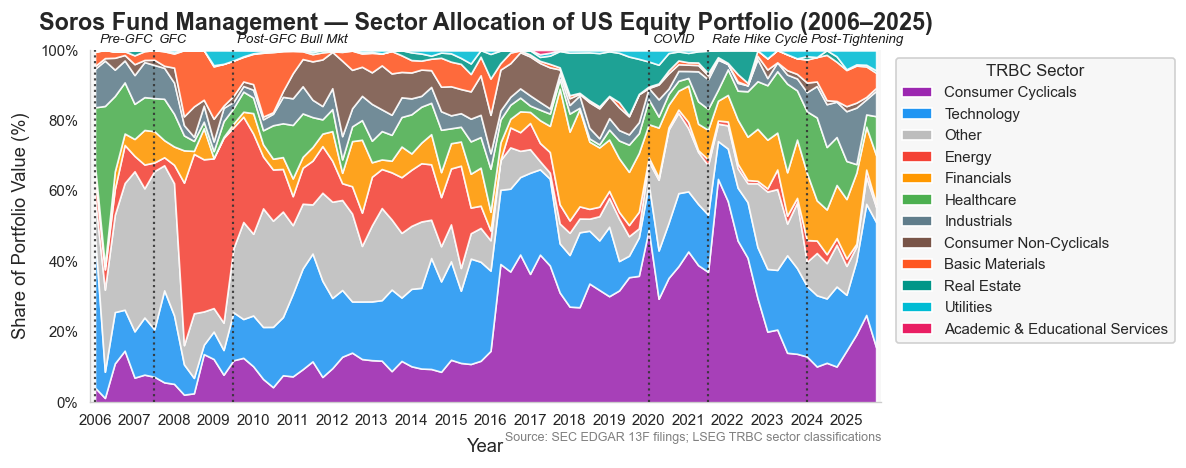

In [14]:
sector_q = (
    sfm.groupby(["quarter", "trbc_economic_sector"])["value_usd"]
    .sum()
    .unstack(fill_value=0)
    .loc[all_quarters]
)
sector_pct   = sector_q.div(sector_q.sum(axis=1), axis=0) * 100
sector_order = sector_pct.mean().sort_values(ascending=False).index.tolist()
sector_pct   = sector_pct[sector_order]
colors       = [SECTOR_PALETTE.get(s, "#BDBDBD") for s in sector_order]
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(all_quarters))
ax.stackplot(x, sector_pct[sector_order].T.values,
             labels=sector_order, colors=colors, alpha=0.88)
ax.set_xticks(year_ticks); ax.set_xticklabels(year_labels)
ax.set_xlim(-0.5, len(all_quarters) - 0.5)
ax.set_ylim(0, 100)
add_regime_lines(ax, all_quarters, label_ypos=0.99, above_plot=True)
ax.set_title("Soros Fund Management — Sector Allocation of US Equity Portfolio (2006–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Portfolio Value (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
handles = [mpatches.Patch(facecolor=SECTOR_PALETTE.get(s, "#BDBDBD"), label=s)
           for s in sector_order]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1),
          title="TRBC Sector", ncol=1)
ax.text(1, -0.11, SOURCE_NOTE, transform=ax.transAxes,
        ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq1_01_sector_allocation.png", dpi=100, bbox_inches="tight")
plt.show()

*Figure 3: Quarterly sector allocation of SFM's US equity portfolio (TRBC weights, 2006Q1–2025Q4).*

Over the 2006-2025 period, no single sector permanently dominated SFM's portfolio. Technology's share grew structurally from the post-GFC period onward, which reflects the sector's rising weight in the US equity market broadly. Brief but sharp deviations from diversification are visible at the regime boundaries, but each is short-lived as the portfolio reverts to a broad allocation within a few quarters. This pattern of temporary concentration followed by rapid reversion is examined in detail by regime in Section 4.2. The clearest long-run structural shift is the sustained rise in Technology and the corresponding decline in "Other" holdings.

#### 4.1.2 Market Capitalisation Profile Over Time

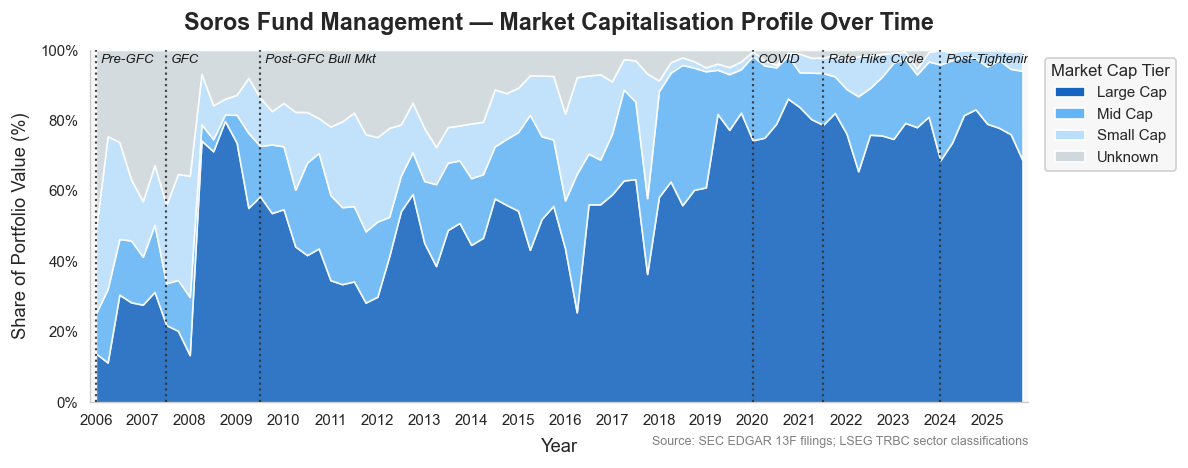

In [15]:
mktcap_order = ["Large Cap", "Mid Cap", "Small Cap", "Unknown"]
mktcap_q = (
    sfm.groupby(["quarter", "mkt_cap_category"])["value_usd"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=mktcap_order, fill_value=0)
    .loc[all_quarters]
)
mktcap_pct = mktcap_q.div(mktcap_q.sum(axis=1), axis=0) * 100
mc_colors  = [MKTCAP_PALETTE[c] for c in mktcap_order]
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(all_quarters))
ax.stackplot(x, mktcap_pct[mktcap_order].T.values,
             labels=mktcap_order, colors=mc_colors, alpha=0.88)
ax.set_xticks(year_ticks); ax.set_xticklabels(year_labels)
ax.set_xlim(-0.5, len(all_quarters) - 0.5)
ax.set_ylim(0, 100)
add_regime_lines(ax, all_quarters, label_ypos=0.99)
ax.set_title("Soros Fund Management — Market Capitalisation Profile Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Portfolio Value (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
handles = [mpatches.Patch(facecolor=MKTCAP_PALETTE[c], label=c) for c in mktcap_order]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1),
          title="Market Cap Tier")
ax.text(1, -0.12, SOURCE_NOTE, transform=ax.transAxes,
        ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq1_02_mktcap_breakdown.png", dpi=100, bbox_inches="tight")
plt.show()

*Figure 4: Quarterly market capitalisation profile of SFM's portfolio (2006Q1–2025Q4).*

Since the GFC, SFM's exposure to small-cap companies has significantly decreased, with the portfolio increasingly concentrated in large-cap names that offer consistent returns, lower idiosyncratic risk, and greater liquidity. This structural shift in market cap preference has persisted through all subsequent regimes, suggesting it reflects a deliberate, long-run change in strategy rather than a temporary crisis response.

#### 4.1.3 Portfolio Concentration: HHI Over Time

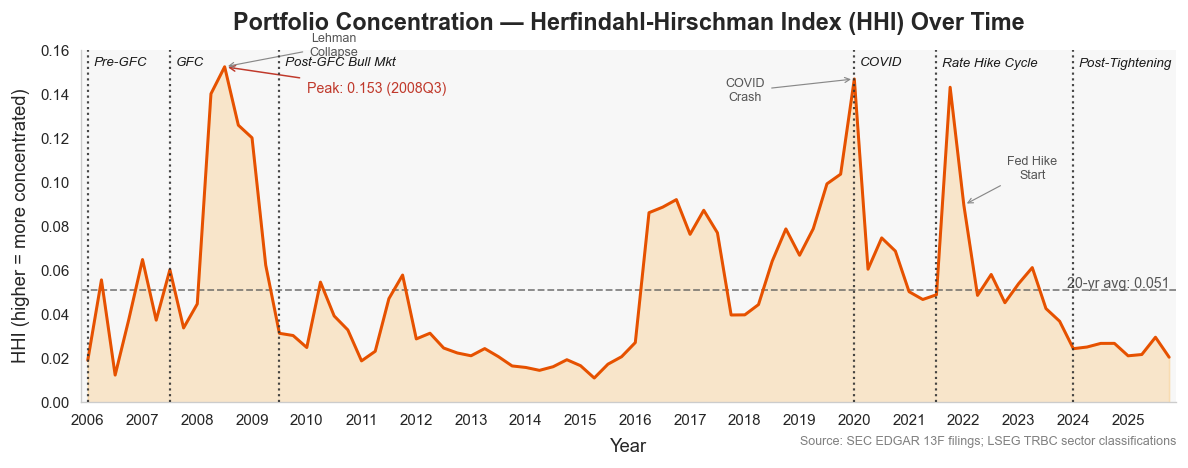

Peak HHI: 0.1527 at 2008Q3
Min  HHI: 0.0111 at 2015Q2
Mean HHI: 0.0510


In [16]:
hhi_q    = sfm.groupby("quarter")["hhi"].first().loc[all_quarters]
mean_hhi = hhi_q.mean()
peak_idx = int(np.argmax(hhi_q.values))
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(all_quarters))
ax.fill_between(x, hhi_q.values, alpha=0.18, color="#FF9800")
ax.plot(x, hhi_q.values, color="#E65100", lw=1.8, zorder=3)
ax.axhline(mean_hhi, color="#555555", lw=1.1, ls="--", alpha=0.7, zorder=2)
ax.text(len(all_quarters) - 1, mean_hhi * 1.02,
        f"20-yr avg: {mean_hhi:.3f}", ha="right", fontsize=8.5, color="#555555")
peak_q = all_quarters[peak_idx]
ax.annotate(f"Peak: {hhi_q.values[peak_idx]:.3f} ({peak_q})",
            xy=(peak_idx, hhi_q.values[peak_idx]),
            xytext=(peak_idx + 6, hhi_q.values[peak_idx] - 0.012),
            fontsize=8.5, color="#C0392B",
            arrowprops=dict(arrowstyle="->", color="#C0392B", lw=0.9))
# ── Macro event annotations ──────────────────────────────────────────────────
EVENTS = [
    ("2008Q3", "Lehman\nCollapse",  8,  0.005),
    ("2020Q1", "COVID\nCrash",     -8, -0.010),
    ("2022Q1", "Fed Hike\nStart",   5,  0.012),
]
for eq, label, dx, dy in EVENTS:
    if eq in all_quarters:
        ex, ey = quarter_idx[eq], hhi_q[eq]
        ax.annotate(label, xy=(ex, ey), xytext=(ex+dx, ey+dy),
                    fontsize=7.5, color="#555555", ha="center",
                    arrowprops=dict(arrowstyle="->", color="#888888", lw=0.7))
ax.set_xticks(year_ticks); ax.set_xticklabels(year_labels)
ax.set_xlim(-0.5, len(all_quarters) - 0.5)
ax.set_ylim(bottom=0)
add_regime_lines(ax, all_quarters, label_ypos=0.98)
ax.set_title("Portfolio Concentration — Herfindahl-Hirschman Index (HHI) Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("HHI (higher = more concentrated)")
ax.text(1, -0.12, SOURCE_NOTE, transform=ax.transAxes,
        ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq1_03_hhi_concentration.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Peak HHI: {hhi_q.values[peak_idx]:.4f} at {peak_q}")
print(f"Min  HHI: {hhi_q.min():.4f} at {hhi_q.idxmin()}")
print(f"Mean HHI: {mean_hhi:.4f}")

*Figure 5: HHI portfolio concentration for SFM, 2006 Q1–2025 Q4 (the dashed line is the 20-year mean of 0.051).*

HHI measures portfolio concentration, with a lower score indicating greater diversification. SFM's HHI ranged from 0.011 in 2015-Q2 to 0.153 in 2008-Q3, during the Lehman collapse, a 14-fold range. Whether this concentration is pre-emptive or reactive is examined in detail in Section 4.2.

#### 4.1.4 Portfolio Turnover Rate Over Time

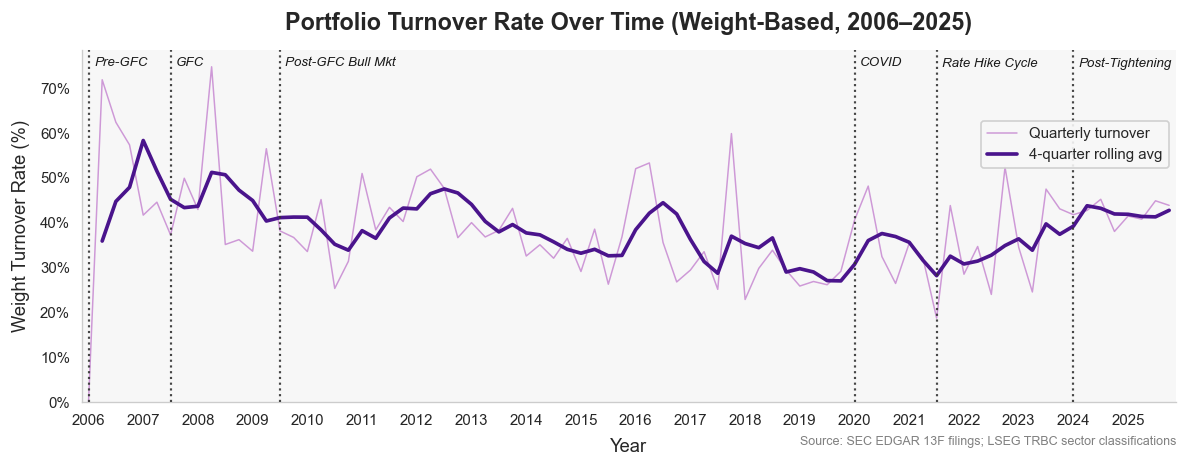

Mean turnover  : 38.6%
Median turnover: 37.1%
Peak quarter   : 2008Q2 (74.8%)


In [17]:
# Weight-based turnover — immune to the pre/post-2023 value scaling discontinuity.
# For each quarter: sum of all portfolio-weight *decreases* (reductions + full exits).
# Captured by pivoting weights wide, differencing, and summing negative changes per quarter.
weight_pivot = sfm.pivot_table(index="quarter", columns="cusip", values="weight", fill_value=0)
weight_pivot = weight_pivot.loc[all_quarters]            # canonical order
weight_diff  = weight_pivot.diff()                       # Q-on-Q change per CUSIP
wt_turnover  = (-weight_diff.clip(upper=0)).sum(axis=1)  # sum of weight decreases
# 4-quarter rolling average
wt_roll = wt_turnover.rolling(4, min_periods=2).mean()
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(all_quarters))
ax.plot(x, wt_turnover.values * 100, color="#9C27B0",
        lw=0.9, alpha=0.45, label="Quarterly turnover")
ax.plot(x, wt_roll.values * 100, color="#4A148C",
        lw=2.2, label="4-quarter rolling avg")
add_regime_lines(ax, all_quarters, label_ypos=0.98)
ax.set_xticks(year_ticks); ax.set_xticklabels(year_labels)
ax.set_xlim(-0.5, len(all_quarters) - 0.5)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Portfolio Turnover Rate Over Time (Weight-Based, 2006–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Weight Turnover Rate (%)")
# Legend moved below regime label strip to avoid overlap
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.82))
ax.text(1, -0.12, SOURCE_NOTE, transform=ax.transAxes,
        ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq1_04_turnover_rate.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Mean turnover  : {wt_turnover.mean() * 100:.1f}%")
print(f"Median turnover: {wt_turnover.median() * 100:.1f}%")
print(f"Peak quarter   : {wt_turnover.idxmax()} ({wt_turnover.max() * 100:.1f}%)")

*Figure 6: Weight-based quarterly turnover for SFM, 2006 Q1–2025 Q4, with 4-quarter rolling average.*

SFM's average turnover was 38.6% per quarter, peaking at 74.8% in 2008-Q2, the quarter before Lehman collapsed. That spike confirms that SFM repositioned itself ahead of the GFC's worst phase, reaffirming that SFM adapts to economic regime changes quickly. The post-2012 decline in turnover, which coincided with quantitative easing suppressing volatility, suggests SFM shifted from opportunistic trading towards longer-duration strategic positioning. The COVID and rate hike cycle spikes confirm that sharp dislocations still trigger repositioning, though at a smaller scale than the GFC.

### 4.2 RQ2: Regime Analysis
RQ2 is **"How did Soros Fund Management readjust its US equity holdings and portfolio concentration during major market regimes (2008 Global Financial Crisis (GFC), COVID-19 Pandemic, and the 2022 rate-hike cycle)?"**. 

The 2006–2025 window is divided into six regimes based on macroeconomic turning points. Each is examined across sector allocation, deviation from the 20-year average, and HHI changes before, during, and after.

**Table 1: Market regime definitions.**
| Regime | Window | Characterisation |
|--------|--------|------------------|
| Pre-GFC | 2006Q1–2007Q2 | Benign credit expansion |
| GFC | 2007Q3–2009Q2 | Global financial crisis |
| Post-GFC Bull Market | 2009Q3–2019Q4 | QE-driven expansion |
| COVID | 2020Q1–2021Q2 | Pandemic crash and recovery |
| Rate Hike Cycle | 2021Q3–2023Q4 | Fed tightening |
| Post-Tightening Bull Market | 2024Q1–2025Q4 | Soft-landing, risk-on |

#### 4.2.1 Sector Allocation Zoom-in: GFC, COVID, and Rate Hike Cycle

Each panel shows the quarterly sector allocation two quarters *before*, *during*, and two quarters *after* each stress regime.

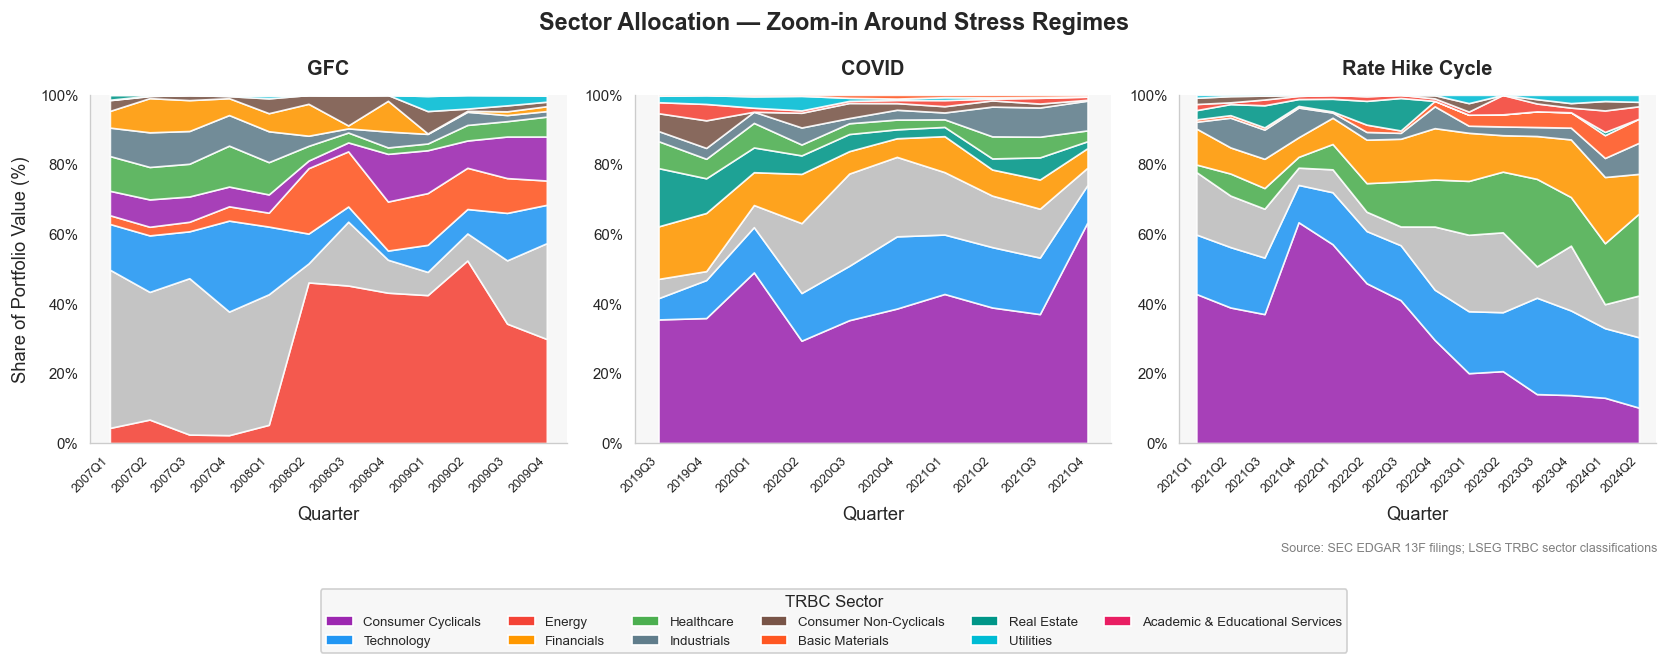

In [18]:
STRESS_REGIMES = [
    ("GFC",             "2007Q1", "2009Q4"),
    ("COVID",           "2019Q3", "2021Q4"),
    ("Rate Hike Cycle", "2021Q1", "2024Q2"),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)
for ax, (name, zoom_start, zoom_end) in zip(axes, STRESS_REGIMES):
    zoom_qs = [q for q in all_quarters if zoom_start <= q <= zoom_end]
    x_zoom  = np.arange(len(zoom_qs))
    sub = sfm[sfm["quarter"].isin(zoom_qs)]
    sq  = (
        sub.groupby(["quarter", "trbc_economic_sector"])["value_usd"]
        .sum()
        .unstack(fill_value=0)
        .reindex(zoom_qs, fill_value=0)
    )
    sp = sq.div(sq.sum(axis=1), axis=0) * 100
    s_order = sp.mean().sort_values(ascending=False).index.tolist()
    colors  = [SECTOR_PALETTE.get(s, "#BDBDBD") for s in s_order]
    ax.stackplot(x_zoom, sp[s_order].T.values, colors=colors, alpha=0.88)
    step = max(1, len(zoom_qs) // 8)
    ax.set_xticks(x_zoom[::step])
    ax.set_xticklabels(zoom_qs[::step], rotation=45, ha="right", fontsize=7.5)
    ax.set_xlim(-0.5, len(zoom_qs) - 0.5)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Quarter")
axes[0].set_ylabel("Share of Portfolio Value (%)")
handles = [mpatches.Patch(facecolor=SECTOR_PALETTE.get(s, "#BDBDBD"), label=s)
           for s in sector_order if s != "Other"]
fig.legend(handles=handles, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5, -0.22), title="TRBC Sector", fontsize=8)
fig.suptitle("Sector Allocation — Zoom-in Around Stress Regimes", fontsize=14, fontweight="bold")
fig.text(0.99, -0.02, SOURCE_NOTE, ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq2_06_sector_zoom.png", dpi=100, bbox_inches="tight")
plt.show()

*Figure 7: Sector allocation across regimes, two quarters before, during, and after GFC, COVID, and the Rate Hike Cycle.*

The three panels reveal that each crisis prompted a qualitatively different portfolio response. 

1) The GFC triggered a defensive reallocation. Financials were cut ahead of the worst of the crisis while exposure to Energy and Basic Materials, sectors resilient to economic downturn, was increased.

2) COVID produced the opposite, an intentional opportunistic bet into Consumer Cyclicals, capturing the surge in demand from stay-at-home consumers. 

3) The rate-hike cycle sees a third pattern marked by gradual de-risking of the portfolio. For instance, exposure to Consumer Cyclicals was reduced due to interest rate sensitivity that weighed household spending. However, SFM did not concentrate in any specific sector.

Taken together, the panels show that SFM does not apply the same playbook to every crisis. The response depends on the nature of the shock.

#### 4.2.2 Sector Rotation Heatmap: Deviation from 20-Year Average

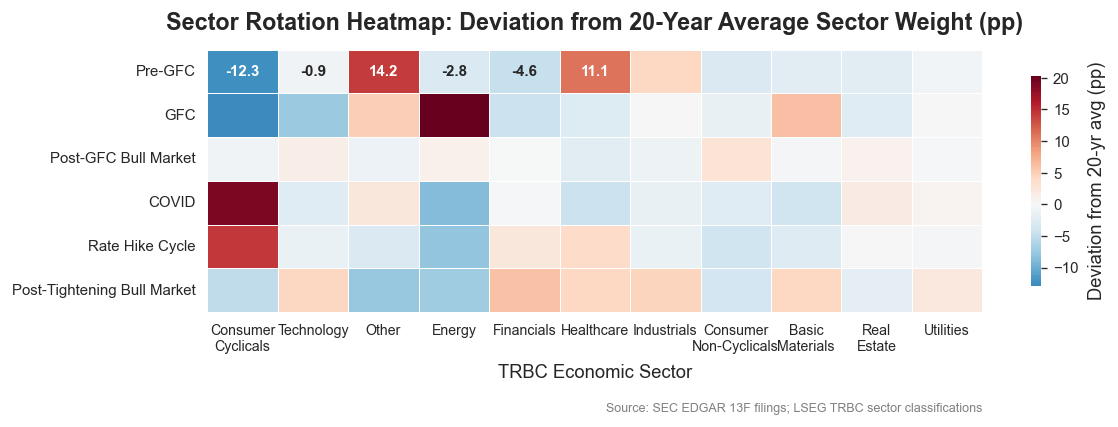

In [19]:
sector_q_pct = (
    sfm.groupby(["quarter", "trbc_economic_sector"])["value_usd"]
    .sum()
    .unstack(fill_value=0)
    .loc[all_quarters]
)
sector_q_pct = sector_q_pct.div(sector_q_pct.sum(axis=1), axis=0) * 100
all_named_regimes = [r[0] for r in REGIMES]
regime_map = {q: assign_regime(q) for q in all_quarters}
sector_q_pct["regime"] = [regime_map[q] for q in sector_q_pct.index]
regime_avg = (
    sector_q_pct[sector_q_pct["regime"].isin(all_named_regimes)]
    .groupby("regime")[sector_order]
    .mean()
    .loc[all_named_regimes]
)
overall_avg = sector_q_pct[sector_order].mean()
deviation   = regime_avg.subtract(overall_avg, axis=1)
keep_sectors = deviation.abs().max(axis=0)
keep_sectors = keep_sectors[keep_sectors > 0.3].index.tolist()
deviation    = deviation[keep_sectors]
_hm_data = deviation.fillna(0)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    _hm_data,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 9, "fontweight": "bold"},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Deviation from 20-yr avg (pp)", "shrink": 0.8},
)
ax.set_title("Sector Rotation Heatmap: Deviation from 20-Year Average Sector Weight (pp)")
ax.set_xlabel("TRBC Economic Sector")
ax.set_ylabel("")
_xlabels = [t.get_text() for t in ax.get_xticklabels()]
_xlabels = [s.replace(' ', '\n', 1) if len(s) > 10 else s for s in _xlabels]
ax.set_xticklabels(_xlabels, rotation=0, ha="center", fontsize=8.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.text(1, -0.38, SOURCE_NOTE, transform=ax.transAxes,
        ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq2_07_sector_rotation_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()

*Figure 8: Regime-average sector weight deviation from the 20-year mean (pp). Blue = underweight, red = overweight.*

The heatmap reveals each regime has a distinct sector "fingerprint." Consumer Cyclicals shows the largest deviations, sharply underweight during the GFC and sharply overweight during COVID. This is a mirror image that reflects the opposite nature of these two crises (financial system shock vs. demand-side stimulus). 

Energy tells the reverse story: overweight during the GFC and progressively underweighted in every subsequent regime, consistent with the post-GFC global energy transition narrative. 

The rate-hike cycle and post-tightening period show the flattest deviations overall, suggesting SFM's response to monetary tightening was primarily a de-risking of specific exposures rather than a wholesale sector rotation. The "Other" row shrinking over time corroborates the small-cap-to-large-cap shift identified in RQ1.

#### 4.2.3 Portfolio Concentration Change Around Each Regime

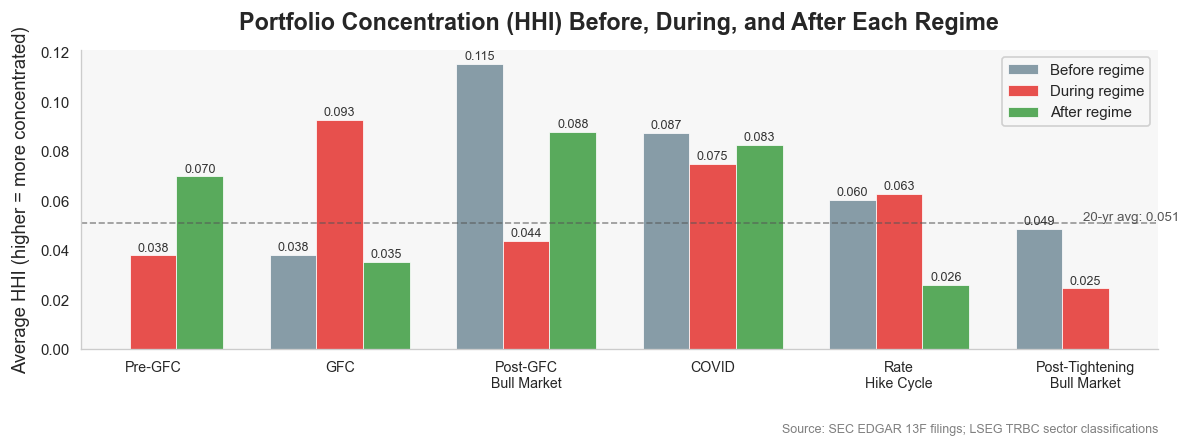

In [20]:
def mean_hhi_window(quarters_list):
    valid = [q for q in quarters_list if q in hhi_q.index]
    return hhi_q[valid].mean() if valid else np.nan
bda_records = []
for name, start, end, *_ in REGIMES:
    si = quarter_idx[start]
    ei = quarter_idx[end]
    before_qs = all_quarters[max(0, si - 4) : si]
    during_qs = all_quarters[si : ei + 1]
    after_qs  = all_quarters[ei + 1 : min(len(all_quarters), ei + 5)]
    bda_records.append({
        "Regime": name,
        "Before": mean_hhi_window(before_qs),
        "During": mean_hhi_window(during_qs),
        "After":  mean_hhi_window(after_qs),
    })
bda = pd.DataFrame(bda_records).set_index("Regime")
bar_width = 0.25
x_pos     = np.arange(len(bda))
BAR_COLORS = {"Before": "#78909C", "During": "#E53935", "After": "#43A047"}
fig, ax = plt.subplots(figsize=(10, 4))
for i, phase in enumerate(["Before", "During", "After"]):
    offsets = x_pos + (i - 1) * bar_width
    bars = ax.bar(offsets, bda[phase], bar_width,
                  label=f"{phase} regime", color=BAR_COLORS[phase],
                  alpha=0.88, edgecolor="white", linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.0005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7.5, color="#333333")
ax.set_xticks(x_pos)
_xlabels = []
for lbl in bda.index:
    if len(lbl) > 8 and ' ' in lbl:
        idx = lbl.index(' ')
        _xlabels.append(lbl[:idx] + '\n' + lbl[idx+1:])
    else:
        _xlabels.append(lbl)
ax.set_xticklabels(_xlabels, fontsize=8.5, rotation=0, ha="center")
ax.set_ylabel("Average HHI (higher = more concentrated)")
ax.set_ylim(bottom=0)
ax.axhline(mean_hhi, color="#555555", lw=1, ls="--", alpha=0.6)
ax.text(len(bda) - 0.5, mean_hhi * 1.02,
        f"20-yr avg: {mean_hhi:.3f}", ha="right", fontsize=8, color="#555555")
ax.set_title("Portfolio Concentration (HHI) Before, During, and After Each Regime")
ax.legend(loc="upper right")
ax.text(1, -0.28, SOURCE_NOTE, transform=ax.transAxes,
        ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq2_08_hhi_before_during_after.png", dpi=100, bbox_inches="tight")
plt.show()

*Figure 9: Before/During/After HHI for all six regimes (mean of four quarters each window).*

The before/during/after HHI data reveals three structurally different concentration patterns across the stress regimes. 

1. Before the GFC, HHI was below the 20-year mean (0.038), then more than doubled to 0.093 during it (the highest reading of any regime) before rapidly unwinding to 0.035 after. Concentration built within the crisis itself rather than ahead of it, making the GFC response reactive and extreme. 

2. COVID shows the opposite structure. HHI was already elevated before (0.087), remained above average during (0.075), and stayed elevated after (0.083). There were no sharp spikes, just persistent concentration across the entire period. 

3. The rate-hike cycle shows a third pattern. Before and during are nearly identical (0.060 vs 0.063), but the after value (0.026) is the lowest in the dataset, suggesting SFM aggressively diversified once tightening ended.

4. The Post-GFC Bull Market is the only regime where all three windows sit comfortably below the 20-year mean, with a regime-average HHI of 0.044 confirming it as SFM's most broadly diversified phase across the full sample.

Across regimes, SFM's concentration level was shaped by the nature of the shock rather than a single consistent strategy. The GFC triggered a reactive spike, COVID produced persistent concentration, the rate-hike cycle ended in aggressive post-tightening diversification, and the Post-GFC Bull Market remained uniformly low throughout.

### 4.3 RQ3: Cross-Fund Comparison
RQ3 is **"How does Soros Fund Management’s sector and market cap profile compare to Pershing Square and Marshall Wace from 2006-2025?"**. 

The three funds have different strategies: SFM is a discretionary macro fund that invests in industries more broadly, Pershing Square is a concentrated activist fund that attempts to influence governance of companies to better their investments, and Marshall Wace is a quantitative long-short that uses complex mathematical models to predict investment opportunities. Their disclosed equity profiles reflect those differences.

#### 4.3.1 Weighted Portfolio Returns

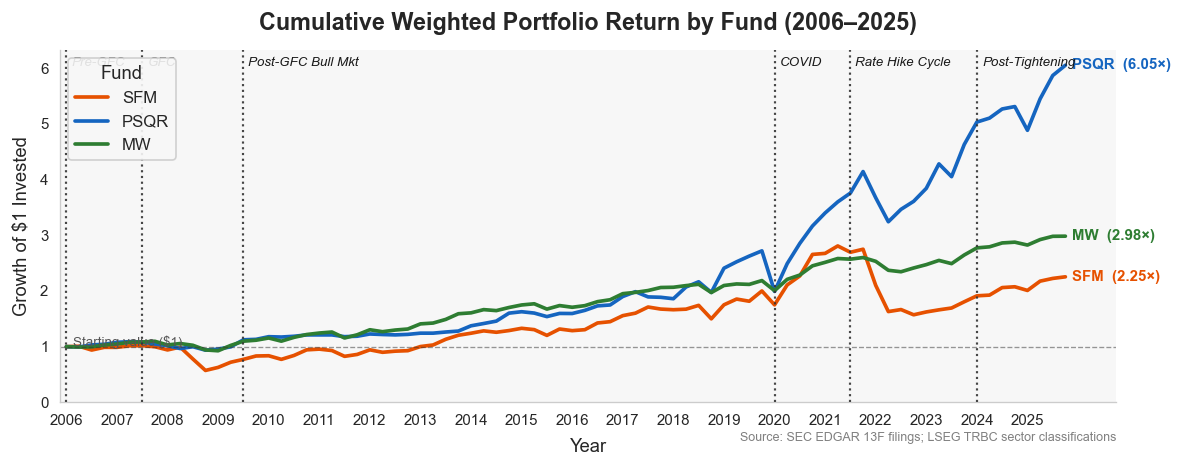

SFM: $1.00 → $2.25  (total return: +125.4%,  quarters: 79)
PSQR: $1.00 → $6.05  (total return: +505.3%,  quarters: 79)
MW: $1.00 → $2.98  (total return: +198.4%,  quarters: 79)


In [21]:
FUNDS = ["Soros Fund Management", "Pershing Square", "Marshall Wace"]
FUND_SHORT = {
    "Soros Fund Management": "SFM",
    "Pershing Square":       "PSQR",
    "Marshall Wace":         "MW",
}
FUND_COLOURS = {
    "Soros Fund Management": "#E65100",
    "Pershing Square":       "#1565C0",
    "Marshall Wace":         "#2E7D32",
}
compare = master[master["fund"].isin(FUNDS)].copy()
compare["regime"] = compare["quarter"].apply(assign_regime)
all_q_compare = sorted(
    compare["quarter"].unique(),
    key=lambda q: (int(q[:4]), int(q[5]))
)
fund_returns = {}
for fund in FUNDS:
    fund_df = compare[compare["fund"] == fund].copy()
    if fund_df["close_price"].dropna().empty:
        continue
    price_pivot = fund_df.pivot_table(
        index="quarter", columns="cusip",
        values="close_price", aggfunc="first"
    )
    fund_quarters = [q for q in all_q_compare if q in price_pivot.index]
    price_pivot = price_pivot.loc[fund_quarters]
    price_prev   = price_pivot.shift(1)
    stock_return = (price_pivot - price_prev) / price_prev
 
    weight_pivot = fund_df.pivot_table(
        index="quarter", columns="cusip",
        values="weight", aggfunc="first", fill_value=0
    )
    weight_pivot = weight_pivot.reindex(index=fund_quarters, columns=price_pivot.columns, fill_value=0)
    # Weighted return per quarter = sum of (stock_return × weight) across all stocks
    # Use the weight at the START of the quarter (i.e., previous quarter's weight)
    # to avoid look-ahead bias. If you prefer current-quarter weights, remove .shift(1).
    weights_used     = weight_pivot.shift(1)
    weighted_returns = (stock_return * weights_used).sum(axis=1)
    weighted_returns = weighted_returns.dropna()
    fund_returns[fund] = weighted_returns
cumulative = {}
for fund, ret_series in fund_returns.items():
    cum = (1 + ret_series).cumprod()
    # Prepend 1.0 at the quarter before the first return (the starting point)
    start_q = ret_series.index[0]
    start_idx = all_q_compare.index(start_q)
    if start_idx > 0:
        prev_q = all_q_compare[start_idx - 1]
        cum = pd.concat([pd.Series([1.0], index=[prev_q]), cum])
    cumulative[fund] = cum
fig, ax = plt.subplots(figsize=(10, 4))
all_plot_quarters = sorted(
    set().union(*(cum.index for cum in cumulative.values())),
    key=lambda q: (int(q[:4]), int(q[5]))
)
x_map = {q: i for i, q in enumerate(all_plot_quarters)}
for fund, cum in cumulative.items():
    x_vals = [x_map[q] for q in cum.index]
    ax.plot(
        x_vals, cum.values,
        color=FUND_COLOURS[fund], lw=2.2, label=FUND_SHORT[fund],
    )
    ax.text(
        x_vals[-1] + 0.5, cum.values[-1],
        f"{FUND_SHORT[fund]}  ({cum.values[-1]:.2f}×)",
        ha="left", va="center", fontsize=9,
        color=FUND_COLOURS[fund], fontweight="bold",
    )
ax.axhline(1.0, color="#333333", lw=0.8, ls="--", alpha=0.5)
ax.text(0.5, 1.01, "Starting value ($1)", fontsize=8, color="#555555")
yr_ticks  = [i for i, q in enumerate(all_plot_quarters) if q.endswith("Q1")]
yr_labels = [all_plot_quarters[i][:4] for i in yr_ticks]
add_regime_lines(ax, all_plot_quarters, label_ypos=0.98)
ax.set_xticks(yr_ticks)
ax.set_xticklabels(yr_labels)
ax.set_xlim(-0.5, len(all_plot_quarters) + 3)
ax.set_ylim(bottom=0)
ax.set_title(
    "Cumulative Weighted Portfolio Return by Fund (2006–2025)",
    fontsize=14, fontweight="bold",
)
ax.set_xlabel("Year")
ax.set_ylabel("Growth of $1 Invested")
ax.legend(loc="upper left", fontsize=10, title="Fund", title_fontsize=11)
ax.text(1, -0.11, SOURCE_NOTE,
        transform=ax.transAxes, ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq3_02_cumulative_return.png",
            dpi=100, bbox_inches="tight")
plt.show()
for fund, cum in cumulative.items():
    total = cum.values[-1]
    print(f"{FUND_SHORT[fund]}: ${1:.2f} → ${total:.2f}  "
          f"(total return: {(total - 1) * 100:+.1f}%,  "
          f"quarters: {len(cum) - 1})")

*Figure 10: Cumulative portfolio-weighted quarterly returns: SFM, Pershing Square, Marshall Wace (2006 Q1–2025 Q4).*

Aside from the drop in 2022, SFM's returns have moderate volatility reflecting its well-diversified macro approach. Conversely, Pershing Square's concentrated activist approach has delivered a 6.05x cumulative return, nearly 3x SFM's, but at the cost of deeper drawdowns. Marshall Wace achieved nearly 3x return with the smoothest trajectory of the three, reflecting its quantitative long-short approach which hedges much of the market-directional risk that SFM and Pershing Square carry.

#### 4.3.2 Market Cap Profile by Fund

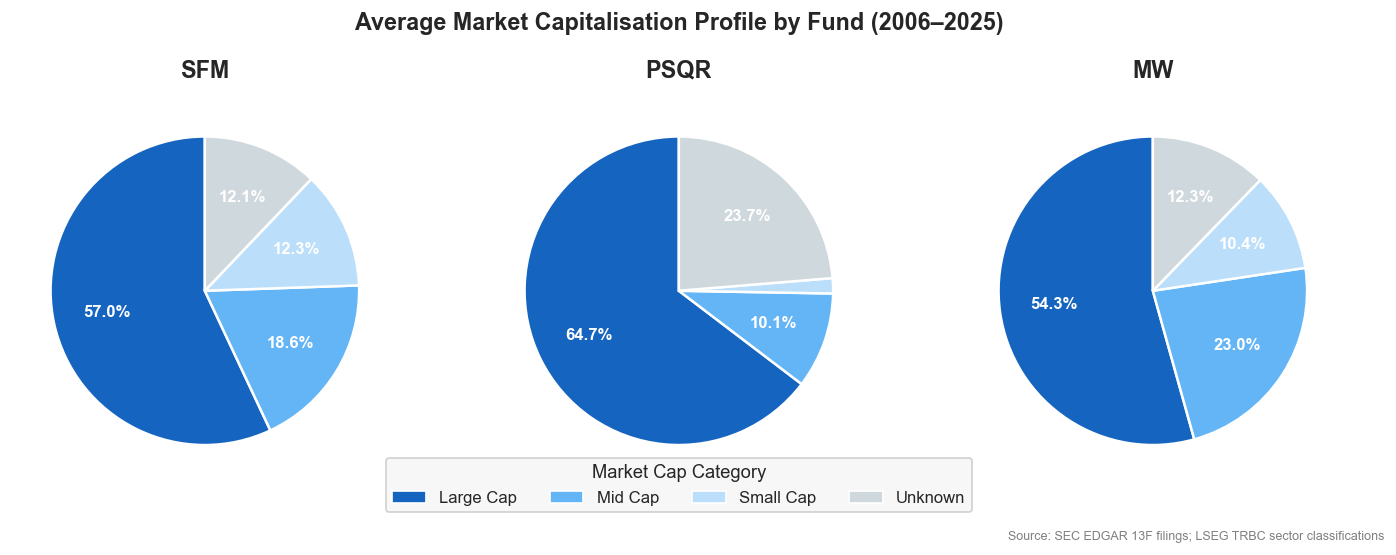

In [22]:
# Fund setup ─────────────────────────────────────────────────────────────
FUNDS = ["Soros Fund Management", "Pershing Square", "Marshall Wace"]
FUND_SHORT = {
    "Soros Fund Management": "SFM",
    "Pershing Square":       "PSQR",
    "Marshall Wace":         "MW",
}
compare = master[master["fund"].isin(FUNDS)].copy()
compare["mkt_cap_category"] = compare["mkt_cap_category"].fillna("Unknown")
mktcap_order  = ["Large Cap", "Mid Cap", "Small Cap", "Unknown"]
mktcap_colors = [MKTCAP_PALETTE[c] for c in mktcap_order]
fund_avg = {}
for fund in FUNDS:
    fund_df = compare[compare["fund"] == fund]
    qtr_mktcap = (
        fund_df.groupby(["quarter", "mkt_cap_category"])["value_usd"]
        .sum()
        .unstack(fill_value=0)
    )
    qtr_pct = qtr_mktcap.div(qtr_mktcap.sum(axis=1), axis=0) * 100
    avg_pct = qtr_pct.reindex(columns=mktcap_order, fill_value=0).mean()
    fund_avg[fund] = avg_pct
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, fund in zip(axes, FUNDS):
    values = fund_avg[fund].values
    labels = mktcap_order
    def make_autopct(vals):
        def autopct(pct):
            return f"{pct:.1f}%" if pct >= 3 else ""
        return autopct
    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,                          # we add labels via legend instead
        autopct=make_autopct(values),
        colors=mktcap_colors,
        startangle=90,
        pctdistance=0.65,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )
    for t in autotexts:
        t.set_fontsize(10)
        t.set_fontweight("bold")
        t.set_color("white")
    ax.set_title(FUND_SHORT[fund], fontsize=14, fontweight="bold", pad=12)
handles = [mpatches.Patch(facecolor=MKTCAP_PALETTE[c], label=c)
           for c in mktcap_order]
fig.legend(
    handles=handles, loc="lower center",
    bbox_to_anchor=(0.5, -0.04), ncol=4, fontsize=10,
    title="Market Cap Category", title_fontsize=11,
)
fig.suptitle(
    "Average Market Capitalisation Profile by Fund (2006–2025)",
    fontsize=14, fontweight="bold", y=1.02,
)
fig.text(0.99, -0.08, SOURCE_NOTE, ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq3_03_mktcap_pie.png",
            dpi=100, bbox_inches="tight")
plt.show()

*Figure 11: Average market cap profile by fund, 2006 Q1–2025 Q4 (proportion of portfolio value by cap tier).*

SFM and Marshall Wace generally have equivalent proportions of their portfolio being allocated to each market cap category, consistent with their broadly similar risk profiles. Pershing Square, on the other hand, has less exposure to small-mid cap companies and rather concentrates on large-cap positions where it can focus on actively influencing corporate strategy.

#### 4.3.3 Sector Allocation by Fund

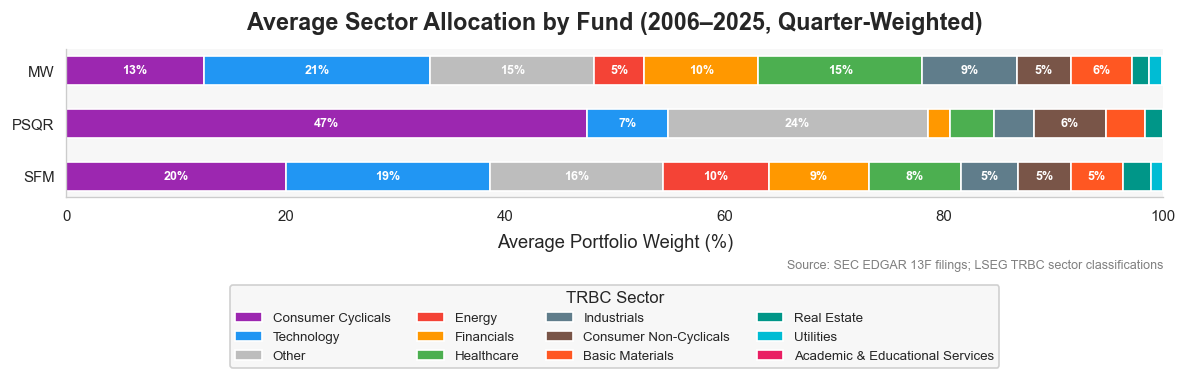

In [23]:
# ── 4.3.3  Average sector allocation by fund (2006–2025, quarter-weighted) ──
_funds_compare = ["Soros Fund Management", "Pershing Square", "Marshall Wace"]
_fund_labels   = ["SFM", "PSQR", "MW"]
_cs = master[master["fund"].isin(_funds_compare)].copy()
_cs["trbc_economic_sector"] = _cs["trbc_economic_sector"].fillna("Other")
_fund_sector_avg = {}
for _fund in _funds_compare:
    _sub = _cs[_cs["fund"] == _fund]
    _qtr = (
        _sub.groupby(["quarter", "trbc_economic_sector"])["value_usd"]
        .sum().unstack(fill_value=0)
    )
    _fund_sector_avg[_fund] = (_qtr.div(_qtr.sum(axis=1), axis=0) * 100).mean()
_avg_df = pd.DataFrame(_fund_sector_avg).T.fillna(0)
# Order sectors by SFM average weight descending
_s_order = _avg_df.loc["Soros Fund Management"].sort_values(ascending=False).index.tolist()
_avg_df  = _avg_df[_s_order]
_colors  = [SECTOR_PALETTE.get(s, "#BDBDBD") for s in _s_order]
fig, ax = plt.subplots(figsize=(10, 4.5))
_left = np.zeros(len(_funds_compare))
for _sector, _color in zip(_s_order, _colors):
    _vals = _avg_df[_sector].values
    ax.barh(_fund_labels, _vals, left=_left, color=_color, label=_sector, height=0.55)
    for _k, (_v, _l) in enumerate(zip(_vals, _left)):
        if _v > 4:
            ax.text(_l + _v / 2, _k, f"{_v:.0f}%", ha="center", va="center",
                    fontsize=7.5, color="white", fontweight="bold")
    _left += _vals
ax.set_xlim(0, 100)
ax.set_xlabel("Average Portfolio Weight (%)")
ax.set_title("Average Sector Allocation by Fund (2006–2025, Quarter-Weighted)")
_handles = [mpatches.Patch(facecolor=SECTOR_PALETTE.get(s, "#BDBDBD"), label=s) for s in _s_order]
ax.legend(handles=_handles, bbox_to_anchor=(0.5, -0.55), loc="upper center",
          ncol=4, fontsize=8, title="TRBC Sector")
ax.text(1, -0.48, SOURCE_NOTE, transform=ax.transAxes, ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rq3_12_sector_by_fund.png", dpi=100, bbox_inches="tight")
plt.show()

*Figure 12: Average sector allocation by fund, 2006 Q1–2025 Q4 (quarter-weighted average portfolio weights).*

The sector profiles reinforce each fund's stated strategy. Pershing Square is heavily concentrated in Consumer Cyclicals (47%), consistent with its activist focus on consumer-facing businesses where it can acquire large stakes and influence governance. SFM is the most evenly distributed, with Consumer Cyclicals (20%) and Technology (19%) as co-dominant sectors and meaningful exposure across Energy, Financials, and Healthcare, reflecting its opportunistic macro mandate. Marshall Wace's largest weights are Technology (21%) and Healthcare (15%), consistent with a quantitative strategy that leans toward large-cap growth and defensive sectors rather than concentrated macro or activist positions.

Despite their similar market cap profiles (Figure 11), SFM and Marshall Wace diverge in sector terms: SFM carries nearly 10% in Energy while Marshall Wace holds under 5%. 

Note that Pershing Square's "Other" category (24%) is elevated due to its lower LSEG sector coverage (72% vs ~88% for the other two funds), so its true Consumer Cyclicals concentration may be even higher than shown.

### 4.4 Explanatory Visualisations
The two charts below synthesise the above sections into a consolidated view of SFM's investment character.

#### 4.4.1 Macro Posture: Risk-On vs Risk-Off


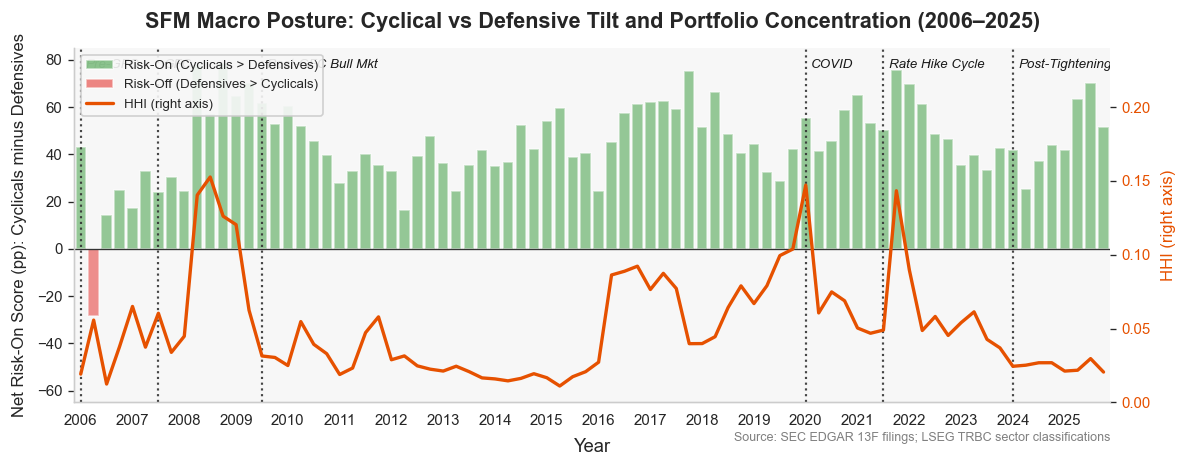

In [24]:
RISK_ON  = ["Technology", "Consumer Cyclicals", "Energy", "Financials", "Basic Materials"]
RISK_OFF = ["Healthcare", "Utilities", "Consumer Non-Cyclicals", "Real Estate"]
avail_on  = [s for s in RISK_ON  if s in sector_pct.columns]
avail_off = [s for s in RISK_OFF if s in sector_pct.columns]
net_risk = sector_pct[avail_on].sum(axis=1) - sector_pct[avail_off].sum(axis=1)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
x = np.arange(len(all_quarters))
bar_colors = ["#E53935" if v < 0 else "#43A047" for v in net_risk.values]
ax1.bar(x, net_risk.values, color=bar_colors, alpha=0.55, width=0.8, zorder=2)
ax1.axhline(0, color="#333333", lw=0.8)
ax1.set_ylabel("Net Risk-On Score (pp): Cyclicals minus Defensives", fontsize=10)
ax1.set_ylim(-65, 85)
ax2.plot(x, hhi_q.values, color="#E65100", lw=2.0, zorder=3)
ax2.set_ylabel("HHI (right axis)", fontsize=10, color="#E65100")
ax2.tick_params(axis="y", labelcolor="#E65100")
ax2.set_ylim(0, 0.24)
add_regime_lines(ax1, all_quarters, label_ypos=0.97)
ax1.set_xticks(year_ticks); ax1.set_xticklabels(year_labels)
ax1.set_xlim(-0.5, len(all_quarters) - 0.5)
green_p = mpatches.Patch(facecolor="#43A047", alpha=0.6, label="Risk-On (Cyclicals > Defensives)")
red_p   = mpatches.Patch(facecolor="#E53935", alpha=0.6, label="Risk-Off (Defensives > Cyclicals)")
line_p  = plt.Line2D([0],[0], color="#E65100", lw=2, label="HHI (right axis)")
ax1.legend(handles=[green_p, red_p, line_p], loc="upper left", fontsize=8)
ax1.set_title("SFM Macro Posture: Cyclical vs Defensive Tilt and Portfolio Concentration (2006–2025)", fontsize=13)
ax1.set_xlabel("Year")
ax1.text(1, -0.11, SOURCE_NOTE, transform=ax1.transAxes, ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/explain_e1_macro_posture.png", dpi=100, bbox_inches="tight")
plt.show()

*Figure 13: Net risk-on sector score (left axis) and HHI concentration (right axis) for SFM, 2006 Q1–2025 Q4.*

The two largest HHI spikes (2008-Q3 and 2020-Q1) both coincide with crisis periods as SFM concentrated its portfolio into resilient or opportunistic sectors at times of crisis rather than taking on risk. The Post-GFC bull market is a sustained risk-on period where SFM spread positions broadly, reflected in its lowest HHI readings (2012–2016), while COVID represents a concentrated opportunistic bet rather than a defensive retreat, consistent with the Consumer Cyclicals overweight shown in Figures 7 and 8.

#### 4.4.2 Regime Scorecard

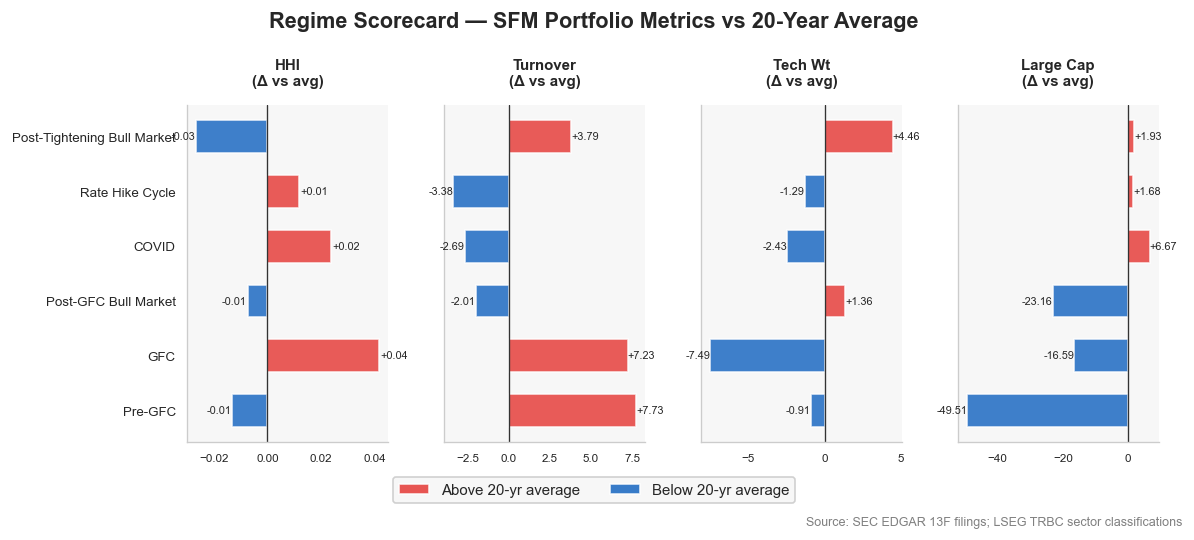

In [25]:
overall_hhi  = sfm.groupby("quarter")["hhi"].first().mean()
overall_tov  = wt_turnover.mean() * 100
overall_tech = sector_pct["Technology"].mean() if "Technology" in sector_pct.columns else 0
overall_lc   = (sfm[sfm["mkt_cap_category"]=="Large Cap"]["value_usd"].sum()
                / sfm["value_usd"].sum() * 100)
scorecard = []
for name, start, end, *_ in REGIMES:
    sub  = sfm[sfm["regime"] == name]
    q_sub = list(sub["quarter"].unique())
    hhi_v  = sub.groupby("quarter")["hhi"].first().mean()
    tov_v  = wt_turnover.loc[q_sub].mean() * 100 if q_sub else float("nan")
    tech_v = sector_pct.loc[q_sub, "Technology"].mean() if "Technology" in sector_pct.columns and q_sub else 0
    lc_v   = (sub[sub["mkt_cap_category"]=="Large Cap"]["value_usd"].sum()
              / sub["value_usd"].sum() * 100)
    scorecard.append({
        "Regime":           name,
        "HHI\n(Δ vs avg)":   hhi_v  - overall_hhi,
        "Turnover\n(Δ vs avg)": tov_v  - overall_tov,
        "Tech Wt\n(Δ vs avg)":  tech_v - overall_tech,
        "Large Cap\n(Δ vs avg)": lc_v   - overall_lc,
    })
sc_df = pd.DataFrame(scorecard).set_index("Regime")
fig, axes = plt.subplots(1, 4, figsize=(10, 4), sharey=True)
fig.subplots_adjust(wspace=0.05)
for ax, col in zip(axes, sc_df.columns):
    vals   = sc_df[col].values
    labels = sc_df.index.tolist()
    colors = ["#E53935" if v >= 0 else "#1565C0" for v in vals]
    bars   = ax.barh(labels, vals, color=colors, alpha=0.82, edgecolor="white", height=0.6)
    ax.axvline(0, color="#333333", lw=0.8)
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=7)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(val + (0.0005 if val >= 0 else -0.0005),
                bar.get_y() + bar.get_height()/2,
                f"{val:+.2f}", va="center",
                ha="left" if val >= 0 else "right", fontsize=6.5)
red_p  = mpatches.Patch(facecolor="#E53935", alpha=0.85, label="Above 20-yr average")
blue_p = mpatches.Patch(facecolor="#1565C0", alpha=0.85, label="Below 20-yr average")
fig.legend(handles=[red_p, blue_p], loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.06), fontsize=9)
fig.suptitle("Regime Scorecard — SFM Portfolio Metrics vs 20-Year Average", fontsize=13, fontweight="bold")
fig.text(0.99, -0.09, SOURCE_NOTE, ha="right", fontsize=7.5, color="gray")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/explain_e3_regime_scorecard.png", dpi=100, bbox_inches="tight")
plt.show()

*Figure 14: Regime scorecard: deviation of four key metrics from 20-year averages, by regime.*

Every economic regime showcases a unique scorecard profile. The GFC is the only time period during which metrics were extreme as compared to the 20-year averages, demonstrating how SFM adapts to extreme macroeconomic climates as a macro fund. The Post-GFC Bull Market was SFM's most passive phase with values closest to the 20-year averages. The COVID pandemic and rate hike cycle also caused deviations from the averages but nothing close to the GFC levels. Moreover, the Post-Tightening is below average on HHI but above on turnover, as the portfolio is being actively diversified, consistent with the post-tightening diversification pattern identified in Figure 9.

## **5. Conclusion**

### 5.1 Key Findings

**RQ1:** SFM's US equity portfolio has changed drastically over the last two decades. Sector exposure shifted constantly but generally remained diversified. Over time, the portfolio also skewed towards large-cap companies that are considered less risky, and away from the smaller ones. Concentration, measured by HHI, averaged 0.051, with the Post-GFC bull market pulling the mean lower. Weight-based turnover averaged 38.6% per quarter, indicating active portfolio management rather than passive buy-and-hold.

**RQ2:** Each regime produced a structurally different portfolio response. The GFC was reactive and extreme: HHI was below the 20-year mean before the crisis (0.038) and surged to 0.093 during it, as SFM shifted towards Energy and away from Financials. COVID showed persistent above-average concentration throughout, with a large opportunistic bet on Consumer Cyclicals capturing stay-at-home demand. The rate-hike cycle showed gradual de-risking. Consumer Cyclicals were reduced and HHI remained broadly stable during tightening, before falling to a record low of 0.026 after, as SFM aggressively diversified once the cycle ended. 

**RQ3:** SFM's macro-driven strategy differs significantly from Pershing Square, which adopts a riskier strategy marked with large drawdowns but larger recoveries. However, SFM's market cap allocation and returns resemble those of Marshall Wace, but Marshall Wace's quantitative strategies have allowed it to face less downside in the last two decades.

**Final Judgement:** SFM shows a consistent pattern in its long US equity positions. Ahead of crises, SFM concentrates assets into the most opportunistic or resilient sectors. Then, during times of economic growth like the Post-GFC bull market, SFM diversifies its portfolio, positioning itself to capitalise on every potential sector. However, it should be noted that the 13F-HR data cannot alone determine the success of SFM as it does not consider derivative, short, and non-US equity holdings. Therefore, while SFM's returns trail its competitors, having access to other financial instruments may contribute to varying outcomes.

### 5.2 Limitations

**13F-HR Filing Constraints:** As mentioned, the 13F-HR filings only disclose long US equity positions, and keep derivative, shorts, and non-US holdings confidential. Therefore, the overall strategy used with hedges and options cannot be fully uncovered and tested for its success. 

**Reporting Time:** 13F filings are posted quarterly and may not reflect the positions held by a fund in between these quarters. This also limits the analysis to see how quickly SFM and other funds adapt their strategy during times of crisis.
    
**Data Coverage & Thresholds:** LSEG covers ~87% of holdings with the rest missing sector and market cap data. There was less data coverage for earlier periods, so strategies used then may be harder to fully pinpoint. Additionally, the thresholds for market cap classifications between large, mid, and small cap companies were kept constant rather than being adjusted for inflation, which could potentially contribute to the higher proportion of large-cap holdings over time. While it is unlikely to materially affect the results, it should be noted.

### 5.3 What Else Could Be Done

**Return Attribution:** Compare SFM's sector allocation decisions to the sector performance of the S&P500 to consider whether those shifts contributed to the overall value of the fund. This can be tested for by identifying the alpha associated with each sector.

**Activist Position Identification:** 13D/13G filings could be used to distinguish governance-motivated from return-motivated positions, and returns attributed to these strategies could be determined. This would give a better scope for understanding the varying strategies used by Pershing Square and SFM to further determine how they influence returns.